# Korea Revenue Forecast — 조회 · 분석 · 시각화 노트북 v5

**예측 결과 테이블** : `korea_revenue_forecast_result` *(indicator: SARIMA / ETS / Theta / Ensemble)*  
**실제값 원천 테이블** : `korea_fs_data_from_DG` *(item_code = 'M000904001', 매출액 (천원))*

### 성장률 측정 기준
| 구분 | 계산 방법 |
|------|----------|
| **4Q 성장률** | 예측 향후 4분기 합산 ÷ 직전 실제 4분기 합산 − 1 |
| **YoY(t)** *(v5)* | FY(t) [실제 발표분 + 예측 미발표분] ÷ FY(t−1) 실제 − 1 |
| **YoY(t+1)** *(v5)* | FY(t+1) 예측 ÷ FY(t) − 1 |
| **8Q 성장률** | 예측 향후 8분기 합산 ÷ 최근 실제 8분기 합산 − 1 |
| **기간 CAGR** | 기하평균 기반 연환산 성장률 |

---

### v2 변경 사항 (v1 대비)
| 변경 | 이유 |
|------|------|
| **이상치 자동 필터링** (`MAX_GROWTH_PCT`, `MAX_FC_RATIO`) | SARIMA/ETS가 일부 종목에서 발산하여 천문학적 값 출력 → 표 레이아웃 붕괴 방지 |
| **표시 단위를 '억원'으로 변환** | 천원 단위 큰 숫자를 그대로 표시하면 셀 폭이 무한 확장 |
| **`anomaly_df` 별도 반환** | 발산 종목을 추적/검증 가능 |
| **셀 폭 max-width 제한** | 단일 이상치가 표 전체를 깨뜨리지 못하도록 방어 |
| **진단 셀 (Cell 11)** 추가 | 발산 종목·모델별 통계 즉시 확인 |

---

| 셀 | 단계 |
|---|---|
| Cell 1 | 환경 설정 & 경로 자동 감지 |
| Cell 2 | 라이브러리 Import & DB 연결 |
| Cell 3 | 파라미터 설정 (이상치 임계값 포함) |
| Cell 4 | 핵심 계산 함수 정의 |
| Cell 5 | 단일 티커 예측치 조회 함수 (`fetch_forecast`) |
| Cell 6 | 단일 티커 조회 테스트 + 증감률 표 |
| Cell 7 | Best-N 기업 추출 함수 (`get_best_n`) |
| Cell 8 | Best-N 추출 테스트 (정상값) |
| Cell 9 | **발산 종목 진단 (`anomaly_df`)** |
| Cell 10 | 단일 티커 시각화 (`plot_ticker_forecast`) |
| Cell 11 | Best-N 성장률 비교 막대 차트 (`plot_best_n_growth`) |
| **Cell 12** | **전종목 매출 성장률 테이블 추출 & Excel 저장 (v4 신규)** |
| **Cell 13** | **연도(FY) 기준 YoY(t) / YoY(t+1) 성장률 — 실제+예측 혼합 (v5 신규)** |


> ### 🔧 v3 패치 (버전 선택 버그 수정)
> **증상**: 재예측 후 일부 종목(예: SK하이닉스 `A000660`)이 1개 분기만 조회됨.
> 
> **원인**: 저장 테이블의 `UNIQUE KEY` 가 `(date,ticker,indicator)` 만으로 된 구스키마라, 재실행 시 `ON DUPLICATE KEY UPDATE` 가 `value` 만 갱신하고 `created_at` 은 최초 실행일로 고정됨. 그 결과 새 예측에서 **새로 생긴 분기만** 최신 `created_at` 을 갖게 되어, `MAX(created_at)` 으로 버전을 고르면 그 분기만 잡힘.
> 
> **수정**: 버전 식별 기준을 `created_at` → **`updated_at`**(매 upsert 마다 갱신)으로 변경. `Cell 3` 에서 `RECENCY_COL` 을 자동 감지하며, `fetch_forecast` / `get_best_n` 가 이를 사용함.
> 
> **권장 영구 조치**: 저장 노트북의 `UNIQUE KEY` 에 `created_at` 을 포함하도록 테이블을 마이그레이션할 것 (아래 셀 참고).

> ### 🆕 v4 패치 (전종목 매출 성장률 Excel 추출)
> **목적**: 유튜브/블로그 콘텐츠용으로 우리나라 전 종목의 **향후 4분기 매출 성장률** 을 한 번에 추출.
>
> **추가**: `Cell 12` — `build_revenue_growth_table()` / `export_revenue_growth_excel()`
>
> | 컬럼 | 정의 |
> |------|------|
> | `ticker` | 종목코드 (A 접두사) |
> | `company_name` | 회사명 *(옵션, `EXPORT_INCLUDE_NAME`)* |
> | `forecast_date` | 예측 실행 버전 날짜 (`RECENCY_COL` 기준) |
> | `revenue_ttm` | 직전 실제 4분기 매출 합산 |
> | `Q+1` ~ `Q+4` | 향후 4분기 예측 매출 |
> | `revenue_forecast_sum` | Q+1~Q+4 합산 |
> | `yoy_growth` | `revenue_forecast_sum / revenue_ttm − 1` (%) — Cell 7 의 `growth_4q_pct` 와 동일 정의 |
>
> - Excel 파일명에 **추출일(YYYYMMDD)** 포함, 저장 폴더는 데스크탑/노트북 자동 감지
> - 시트 3개: `growth`(본 데이터) / `excluded`(제외 종목 + 사유) / `meta`(파라미터·Q+1 분기 분포)
> - 기존 Cell 1~11 은 변경 없음


> ### 🆕 v5 패치 (연도 기준 YoY — 실제 + 예측 혼합 합산)
> **목적**: Cell 12 의 rolling TTM 비교와 별도로, **회계연도 단위** 성장률을 측정.
> 예) 2026 Q1·Q2 실적 발표 후 → `Y0 = 2026 Q1·Q2 실제 + Q3·Q4 예측`, `Y-1 = 2025 실제 4분기`, `Y+1 = 2027 예측 4분기`
>
> **추가**: `Cell 13` — `fetch_fy_growth()` (단일 종목 점검) / `build_fy_growth_table()` / `export_fy_growth_excel()` / `plot_fy_growth_top()`
>
> | 컬럼 | 정의 |
> |------|------|
> | `base_year` | Y0 회계연도 (`FY_BASE_YEAR=None` → Q+1 이 속한 연도의 최빈값으로 자동 결정) |
> | `last_actual_q` | 종목별 마지막 실제 분기 (예: `2026Q2`) — 실적 발표 시차 확인용 |
> | `Y-1` | FY(t−1) 실제 4분기 합 (기본: 4분기 모두 실제값일 때만 계산) |
> | `Y0` | FY(t) 실제(발표분) + 예측(미발표분) 합 |
> | `Y+1` | FY(t+1) 예측 4분기 합 (실제값이 있으면 실제 우선) |
> | `yoy_t` | `Y0 / Y-1 − 1` (%) |
> | `yoy_t1` | `Y+1 / Y0 − 1` (%) |
> | `Y0_mix` | Y0 구성 (`2A+2F` = 실제 2분기 + 예측 2분기) |
> | `Y0_Q1..Q4`, `Y1_Q1..Q4` | 연도별 분기 상세 |
>
> - 분기 귀속은 `(회계연도, 회계분기)` 키로 정규화 → DataGuide 영업일 결산일(`2025-12-30`)도 Q4 로 정상 귀속
> - 같은 분기에 실제·예측이 공존하면 **실제값 우선** (예측 버전이 오래된 경우에도 최신 실적 반영)
> - 연도에 4분기가 모두 채워지지 않으면 제외 + 사유 기록 (`excluded` 시트)
> - Excel: `revenue_fy_growth_{model}_{base_year}_{YYYYMMDD}.xlsx`, 시트 `fy_growth` / `excluded` / `meta`
> - 기존 Cell 1~12 는 변경 없음. Cell 13 은 Cell 12 의 헬퍼(`_load_forecast_and_actual`, `_load_company_names`, 저장 폴더·단위 설정)를 재사용하므로 **Cell 12 함수 정의 셀을 먼저 실행**해야 함


## Cell 1 · 환경 설정 & 경로 자동 감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve()
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root (자동 감지): {root}")
            return root
    for c in _CANDIDATE_ROOTS:
        if os.path.isdir(c):
            if c not in sys.path:
                sys.path.insert(0, c)
            print(f"[PATH] root (후보 경로): {c}")
            return c
    raise EnvironmentError("DATA 폴더를 찾을 수 없습니다. _CANDIDATE_ROOTS를 수정하세요.")

_root = _setup_path()
print(f"[확인] sys.path[0] = {sys.path[0]}")


[PATH] root (자동 감지): C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] sys.path[0] = C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\Korea_Market\analysis\한국기업_매출예측


## Cell 2 · 라이브러리 Import & DB 연결

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

matplotlib.rcParams["font.family"]       = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from DATA.config import get_db_info, get_engine, log

db_info = get_db_info()
engine  = get_engine(db_info)

try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("[OK] DB 연결 성공")
    print(f"     host={db_info['host']}  port={db_info['port']}  db={db_info['database']}")
except Exception as e:
    print(f"[FAIL] DB 연결 실패: {e}")


[OK] DB 연결 성공
     host=192.168.0.230  port=3307  db=investar


## Cell 3 · 파라미터 설정

이 셀에서 이상치 필터링 임계값(`MAX_GROWTH_PCT`, `MAX_FC_RATIO`)을 조정할 수 있습니다.


In [3]:
# ── 예측 결과 테이블 (Korea_revenue_forecast_.py 의 저장 대상) ──
FORECAST_TABLE = "korea_revenue_forecast_result"

# ── 실제값 원천 테이블 (DataGuide 변환본) ──
FS_TABLE          = "korea_fs_data_from_DG"
REVENUE_ITEM_CODE = "M000904001"   # 매출액 (천원)

# ── ticker 형식: True 면 'A005930' (A 접두사 포함) ──
TICKER_HAS_A_PREFIX = True

# ──────────────────────────────────────────────────────────────────────
# 이상치(발산) 필터링 임계값  ── v2 신규
# ──────────────────────────────────────────────────────────────────────
# SARIMA/ETS 같은 모델이 외삽 시 발산하면 매출 예측값이 천문학적으로 커진다.
# 그 결과 styler 의 cell 폭이 폭발해 표 전체 레이아웃이 깨진다.
# 다음 두 임계값으로 명백한 발산 케이스를 best_df 에서 제외한다.
MAX_GROWTH_PCT = 1000.0      # |4Q 또는 8Q 성장률| > 1000% (=10배 성장) 면 발산으로 간주
MAX_FC_RATIO   = 50.0        # 예측 4Q 합 ÷ 실제 4Q 합 비율 > 50배 면 발산으로 간주

# ── 차트 색상 ──
ACTUAL_COLOR   = "#2C3E50"
FORECAST_COLOR = "#E74C3C"
BAR_PALETTE    = [
    "#2ECC71","#3498DB","#9B59B6","#F39C12","#E74C3C",
    "#1ABC9C","#E67E22","#34495E","#E91E63","#00BCD4",
    "#8BC34A","#FF5722","#607D8B","#795548","#9C27B0",
    "#03A9F4","#CDDC39","#FF9800","#673AB7","#009688",
]


def normalize_ticker(ticker) -> str:
    '''
    'A005930' / '005930' / 5930 → 'A005930' (또는 '005930') 으로 통일
    '''
    if isinstance(ticker, int):
        raw = f"{ticker:06d}"
    else:
        raw = str(ticker).strip()
    body = raw[1:] if raw.upper().startswith('A') else raw
    body = body.zfill(6)
    return f"A{body}" if TICKER_HAS_A_PREFIX else body


print("[OK] 파라미터 설정 완료")
print(f"     MAX_GROWTH_PCT = {MAX_GROWTH_PCT}%   (이 값 초과 종목은 발산으로 간주)")
print(f"     MAX_FC_RATIO   = {MAX_FC_RATIO}배   (이 비율 초과 종목은 발산으로 간주)")


# ══════════════════════════════════════════════════════════════════════
# [v3 핵심 수정] 최신 예측 "버전"을 식별하는 기준 컬럼 자동 결정
# ══════════════════════════════════════════════════════════════════════
# ▸ 문제 배경
#   저장 노트북의 테이블이 (date,ticker,indicator) 만으로 UNIQUE KEY 가
#   구성된 구버전 스키마인 경우, 재실행 시 ON DUPLICATE KEY UPDATE 가
#   value 만 갱신하고 created_at 은 '최초 실행일' 그대로 둔다.
#     → 이번 재예측에서 '날짜가 새로 생긴 분기'(예: 2028 Q1)만 새 created_at 을
#       부여받고, 기존과 겹치는 분기(2026 Q2~2027 Q4)는 옛 created_at 으로 남는다.
#     → MAX(created_at) 으로 버전을 고르면 새로 생긴 1개 분기만 잡혀
#       SK하이닉스(A000660)처럼 1개 분기만 출력되는 현상이 발생한다.
#
# ▸ 해결
#   created_at(DATE, 갱신 안 됨) 대신 updated_at(TIMESTAMP, upsert 마다 갱신)
#   을 '실행 버전' 기준으로 사용한다. updated_at 은 INSERT/UPDATE 양쪽 모두
#   현재 시각으로 채워지므로, 한 번의 재실행에서 건드린 모든 분기가 같은 날짜를 갖는다.
def _detect_recency_col() -> str:
    sql = (
        "SELECT COLUMN_NAME FROM information_schema.COLUMNS "
        "WHERE TABLE_SCHEMA = :db AND TABLE_NAME = :tbl"
    )
    with engine.connect() as conn:
        cols = {r[0].lower() for r in conn.execute(
            text(sql), {"db": db_info["database"], "tbl": FORECAST_TABLE}
        ).fetchall()}
    return "updated_at" if "updated_at" in cols else "created_at"


RECENCY_COL = _detect_recency_col()
print(f"     RECENCY_COL    = '{RECENCY_COL}'   (최신 예측 버전 식별 기준)")
if RECENCY_COL == "created_at":
    print("     [주의] updated_at 컬럼이 없어 created_at 기준으로 동작합니다.")
    print("            구스키마(UNIQUE KEY 에 created_at 미포함)면 일부 종목이 누락될 수 있으니")
    print("            저장 테이블에 updated_at 컬럼을 추가하는 것을 권장합니다.")


[OK] 파라미터 설정 완료
     MAX_GROWTH_PCT = 1000.0%   (이 값 초과 종목은 발산으로 간주)
     MAX_FC_RATIO   = 50.0배   (이 비율 초과 종목은 발산으로 간주)
     RECENCY_COL    = 'updated_at'   (최신 예측 버전 식별 기준)


## Cell 4 · 핵심 계산 함수 정의

```
4Q 성장률  = (예측 향후 4Q 합산) / (직전 실제 4Q 합산) - 1
8Q 성장률  = (예측 향후 8Q 합산) / (최근 실제 8Q 합산) - 1
CAGR       = (말기값 / 기초값)^(1/n_years) - 1
```

> 한국 매출 데이터는 **'천원'** 단위. 시각화/표시 단계에서는 자동으로 **억원** 단위로 변환됩니다 (1 억원 = 100,000 천원).


In [4]:
def calc_growth_4q(actual_vals: list, forecast_vals: list):
    '''4Q 성장률: 예측 향후 4Q 합산 / 직전 실제 4Q 합산 - 1'''
    if len(actual_vals) < 4 or len(forecast_vals) < 4:
        return None
    base   = sum(actual_vals[-4:])
    target = sum(forecast_vals[:4])
    if base == 0 or not np.isfinite(base) or not np.isfinite(target):
        return None
    return (target / base - 1) * 100


def calc_growth_8q(actual_vals: list, forecast_vals: list):
    '''8Q 성장률: 예측 향후 8Q 합산 / 최근 실제 8Q 합산 - 1'''
    if len(actual_vals) < 8 or len(forecast_vals) < 8:
        return None
    base   = sum(actual_vals[-8:])
    target = sum(forecast_vals[:8])
    if base == 0 or not np.isfinite(base) or not np.isfinite(target):
        return None
    return (target / base - 1) * 100


def calc_cagr(start_val: float, end_val: float, n_quarters: int):
    '''기하평균 기반 CAGR (연환산). n_quarters = 기간(분기 수)'''
    if start_val is None or end_val is None:
        return None
    if (not np.isfinite(start_val)) or (not np.isfinite(end_val)):
        return None
    if start_val <= 0 or end_val <= 0 or n_quarters <= 0:
        return None
    n_years = n_quarters / 4.0
    try:
        return ((end_val / start_val) ** (1.0 / n_years) - 1) * 100
    except (OverflowError, ValueError):
        return None


def calc_qoq(prev_val: float, curr_val: float):
    '''단순 QoQ 증감률 (연환산 아님)'''
    if prev_val is None or prev_val == 0:
        return None
    if (not np.isfinite(prev_val)) or (not np.isfinite(curr_val)):
        return None
    return (curr_val / prev_val - 1) * 100


def unit_divisor(max_val: float):
    '''
    값 크기에 따른 단위 자동 결정 → (divisor, label)

    매출 데이터가 '천원' 단위로 저장되어 있다고 가정.
        1e9 (천원) = 1 조 원       → '조'
        1e6 (천원) = 10 억 원      → '십억'
        1e3 (천원) = 100 만 원     → '백만'
        else                        → '천'
    '''
    if max_val >= 1e9: return 1e9, "조"
    if max_val >= 1e6: return 1e6, "십억"
    if max_val >= 1e3: return 1e3, "백만"
    return 1, "천"


def qtr_label(dt) -> str:
    '''datetime → YYYY\nQN 형식 레이블'''
    q = (dt.month - 1) // 3 + 1
    return f"{dt.year}\nQ{q}"


# ── styler용 포매터 (v2 신규) ─────────────────────────────────────
def fmt_eok(v):
    '''천원 단위 값을 억원 단위로 변환해 표시 (1 억원 = 100,000 천원)'''
    if v is None:
        return "-"
    if isinstance(v, float) and (not np.isfinite(v)):
        return "발산"
    return f"{v / 1e5:,.0f}"


def fmt_pct(v):
    if v is None or (isinstance(v, float) and (not np.isfinite(v))):
        return "-"
    return f"{v:+.2f}%"


def fmt_pct_yr(v):
    if v is None or (isinstance(v, float) and (not np.isfinite(v))):
        return "-"
    return f"{v:+.2f}%/yr"


print("[OK] 계산 함수 정의 완료")
print("     fmt_eok(v) : '천원' 단위 → '억원' 단위 자동 변환 포매터")


[OK] 계산 함수 정의 완료
     fmt_eok(v) : '천원' 단위 → '억원' 단위 자동 변환 포매터


## Cell 5 · 단일 티커 예측치 조회 함수

`fetch_forecast(ticker, model)` 반환값
- `actual_df` / `forecast_df` : 시계열 DataFrame
- `growth_df`  : 예측 구간 QoQ + 누적 CAGR 표
- `growth_4q`  : 4Q 성장률 (%)
- `growth_8q`  : 8Q 성장률 (%)
- `cagr_total` : 전체 예측 기간 CAGR (%/yr)
- `is_anomaly` : 발산 의심 여부 (Bool, v2 신규)


In [5]:
def fetch_forecast(
    ticker: str,
    model: str,
    forecast_date: str = None,    # str | None  (= 예측 실행 날짜)
) -> dict:
    """
    korea_revenue_forecast_result + korea_fs_data_from_DG 에서
    actual + forecast 를 조회하고 4Q/8Q 성장률 및 CAGR 을 계산해 반환한다.

    forecast_date == None  →  해당 ticker / indicator 의 '가장 최근 실행 버전' 자동 선택

    v3 변경점:
      - 버전 식별 기준을 created_at → RECENCY_COL(기본 updated_at) 로 교체.
        구스키마에서 created_at 이 갱신되지 않아 일부 분기가 누락되던 문제 해결.
      - 한 실행 버전 내에서 (date) 중복 시 가장 최근 갱신분만 사용.
    """
    ticker_norm = normalize_ticker(ticker)
    rc = RECENCY_COL                       # 'updated_at' (권장) | 'created_at'

    # ── 1. 실행 버전(run_date) 결정 ────────────────────────────────────
    #     RECENCY_COL 의 '날짜' 기준. None 이면 가장 최근 실행 버전 자동 선택.
    if forecast_date is None:
        sql_fd = (
            f"SELECT MAX(DATE({rc})) FROM {FORECAST_TABLE} "
            "WHERE ticker=:t AND indicator=:m"
        )
        with engine.connect() as conn:
            row = conn.execute(text(sql_fd),
                               {"t": ticker_norm, "m": model}).fetchone()
        if row is None or row[0] is None:
            raise ValueError(
                f"[{ticker_norm}] indicator='{model}' 예측 데이터가 없습니다."
            )
        run_date = str(row[0])
    else:
        run_date = str(forecast_date)[:10]   # 'YYYY-MM-DD'

    # ── 2. forecast 조회 (해당 실행 버전의 모든 분기) ──────────────────
    sql_fc = (
        f"SELECT date, value, {rc} AS run_ts FROM {FORECAST_TABLE} "
        f"WHERE ticker=:t AND indicator=:m AND DATE({rc})=:fd "
        "ORDER BY date"
    )
    with engine.connect() as conn:
        fc = pd.read_sql(text(sql_fc), conn,
                         params={"t": ticker_norm, "m": model, "fd": run_date})
    if fc.empty:
        raise ValueError(
            f"[{ticker_norm}] indicator='{model}' "
            f"{rc} 날짜='{run_date}' 예측 데이터가 없습니다."
        )

    fc["date"]   = pd.to_datetime(fc["date"])
    fc["run_ts"] = pd.to_datetime(fc["run_ts"])
    fc["value"]  = fc["value"].astype(float)

    # 같은 날짜가 여러 버전으로 잡히면(혼합 스키마) 가장 최근 갱신분만 사용
    fc = (fc.sort_values(["date", "run_ts"])
            .drop_duplicates(subset=["date"], keep="last")
            .reset_index(drop=True))

    forecast_date = run_date
    fc = fc[["date", "value"]].copy()        # 반환 schema 유지 (date, value)

    # ── 3. actual 조회 ──────────────────────────────────────────────────
    fc_first_date = fc["date"].min()
    sql_act = (
        "SELECT date, value FROM {tbl} "
        "WHERE ticker=:t AND item_code=:ic "
        "  AND value IS NOT NULL AND date < :cutoff "
        "ORDER BY date"
    ).format(tbl=FS_TABLE)
    with engine.connect() as conn:
        act = pd.read_sql(text(sql_act), conn,
                          params={"t": ticker_norm,
                                  "ic": REVENUE_ITEM_CODE,
                                  "cutoff": fc_first_date.strftime("%Y-%m-%d")})
    if act.empty:
        raise ValueError(
            f"[{ticker_norm}] {FS_TABLE} 매출 실제값이 없습니다."
        )

    act["date"]  = pd.to_datetime(act["date"])
    act["value"] = act["value"].astype(float)

    # 분기 중복 제거
    act = (act.assign(period=act["date"].dt.to_period("Q"))
              .sort_values(["period", "date"])
              .drop_duplicates(subset=["period"], keep="last")
              .drop(columns=["period"])
              .reset_index(drop=True))

    act_vals = act["value"].tolist()
    fc_vals  = fc["value"].tolist()

    # ── 4. 성장률 계산 ──────────────────────────────────────────────────
    g4       = calc_growth_4q(act_vals, fc_vals)
    g8       = calc_growth_8q(act_vals, fc_vals)
    cagr_tot = calc_cagr(act_vals[-1], fc_vals[-1], len(fc_vals))

    # ── 5. 이상치(발산) 판별 ────────────────────────────────────────────
    is_anomaly = False
    anomaly_reason = None

    if not np.all(np.isfinite(fc_vals)):
        is_anomaly, anomaly_reason = True, "예측값에 NaN/inf 포함"
    elif (g4 is not None and abs(g4) > MAX_GROWTH_PCT) or \
         (g8 is not None and abs(g8) > MAX_GROWTH_PCT):
        is_anomaly = True
        anomaly_reason = f"|성장률| > {MAX_GROWTH_PCT}%"
    elif len(act_vals) >= 4 and len(fc_vals) >= 4:
        act_4q_sum = sum(act_vals[-4:])
        fc_4q_sum  = sum(fc_vals[:4])
        if act_4q_sum > 0 and fc_4q_sum / act_4q_sum > MAX_FC_RATIO:
            is_anomaly = True
            anomaly_reason = f"예측4Q합/실제4Q합 > {MAX_FC_RATIO}배"

    # ── 6. 행별 QoQ + 누적 CAGR 표 ──────────────────────────────────────
    rows = []
    prev = act_vals[-1]
    for i, (dt, v) in enumerate(zip(fc["date"], fc_vals)):
        qoq      = calc_qoq(prev, v)
        cum_cagr = calc_cagr(act_vals[-1], v, i + 1)
        rows.append({
            "분기"        : qtr_label(dt),
            "date"        : dt,
            "예측값"      : round(v, 0) if np.isfinite(v) else None,
            "QoQ(%)"      : round(qoq, 2)      if qoq      is not None else None,
            "누적CAGR(%)": round(cum_cagr, 2) if cum_cagr is not None else None,
        })
        prev = v if np.isfinite(v) else prev

    growth_df = pd.DataFrame(rows)

    return {
        "ticker"       : ticker_norm,
        "model"        : model,
        "forecast_date": forecast_date,
        "actual_df"    : act,
        "forecast_df"  : fc,
        "growth_df"    : growth_df,
        "growth_4q"    : round(g4,       2) if g4       is not None else None,
        "growth_8q"    : round(g8,       2) if g8       is not None else None,
        "cagr_total"   : round(cagr_tot, 2) if cagr_tot is not None else None,
        "is_anomaly"   : is_anomaly,
        "anomaly_reason": anomaly_reason,
    }


print("[OK] fetch_forecast 함수 정의 완료 (v3: RECENCY_COL 기준 최신 버전 선택)")


[OK] fetch_forecast 함수 정의 완료 (v3: RECENCY_COL 기준 최신 버전 선택)


## Cell 6 · 단일 티커 조회 테스트 + 증감률 표

`TEST_TICKER` / `TEST_MODEL` 을 원하는 값으로 변경하세요.  
ticker 는 'A005930' / '005930' / 5930 어느 형태든 입력 가능합니다.


In [6]:
TEST_TICKER = "A278470"       # 삼성전자 (예시)
TEST_MODEL  = "Ensemble"       # SARIMA / ETS / Theta / Ensemble

res = fetch_forecast(TEST_TICKER, TEST_MODEL)
div, unit = unit_divisor(res["actual_df"]["value"].max())

# 요약
print("=" * 70)
print(f"  Ticker        : {res['ticker']}")
print(f"  Model         : {res['model']}")
print(f"  forecast_date : {res['forecast_date']}   (= created_at)")
print(f"  기준값(actual 마지막) : {res['actual_df']['value'].iloc[-1] / div:.2f} {unit}원")
print(f"  발산 여부      : {'⚠️  YES (' + res['anomaly_reason'] + ')' if res['is_anomaly'] else 'NO'}")
print("-" * 70)

def _fmt(v, suffix=""):
    return f"{v:+.2f}{suffix}" if v is not None else "N/A"

print(f"  4Q  성장률  (예측4Q합/실제직전4Q합-1) : {_fmt(res['growth_4q'], '%')}")
print(f"  8Q  성장률  (예측8Q합/실제최근8Q합-1) : {_fmt(res['growth_8q'], '%')}")
print(f"  전체 CAGR   (기하평균 연환산)          : {_fmt(res['cagr_total'], '%/yr')}")
print("=" * 70)

# 증감률 표
print()
print(f"  {'분기':<10} {'예측값':>20} {'QoQ(%)':>10} {'누적CAGR(%/yr)':>16}")
print("  " + "-" * 60)
for _, row in res["growth_df"].iterrows():
    pred_v = row["예측값"]
    pred_s = f"{pred_v:>20,.0f}" if pred_v is not None else f"{'발산':>20s}"
    q_s    = f"{row['QoQ(%)']:+.2f}%"       if row["QoQ(%)"]       is not None else "  -"
    cagr_s = f"{row['누적CAGR(%)']:+.2f}%"  if row["누적CAGR(%)"] is not None else "  -"
    print(f"  {row['분기'].replace(chr(10),' '):<10} "
          f"{pred_s} {q_s:>10} {cagr_s:>16}")
print("=" * 70)


  Ticker        : A278470
  Model         : Ensemble
  forecast_date : 2026-08-26   (= created_at)
  기준값(actual 마지막) : 767.53 십억원
  발산 여부      : NO
----------------------------------------------------------------------
  4Q  성장률  (예측4Q합/실제직전4Q합-1) : +82.78%
  8Q  성장률  (예측8Q합/실제최근8Q합-1) : +230.04%
  전체 CAGR   (기하평균 연환산)          : +59.15%/yr

  분기                          예측값     QoQ(%)     누적CAGR(%/yr)
  ------------------------------------------------------------
  2026 Q3             817,512,207     +6.51%          +28.70%
  2026 Q4           1,061,866,924    +29.89%          +91.40%
  2027 Q1           1,093,941,303     +3.02%          +60.40%
  2027 Q2           1,220,462,387    +11.57%          +59.01%
  2027 Q3           1,320,733,357     +8.22%          +54.37%
  2027 Q4           1,703,315,553    +28.97%          +70.14%
  2028 Q1           1,751,169,603     +2.81%          +60.22%
  2028 Q2           1,943,991,993    +11.01%          +59.15%


## Cell 7 · Best-N 기업 추출 함수

`get_best_n(model, n, sort_by, forecast_date)` 반환:
- `best_df` : 정상값 상위 N개 (이상치 제외)
- `used_dates` : 실제 사용된 created_at 리스트
- **`anomaly_df`** : 발산 의심 종목 전체 (v2 신규)

이상치 판별 기준:
1. 예측값에 NaN / inf 포함
2. |4Q 또는 8Q 성장률| > `MAX_GROWTH_PCT`
3. (예측 4Q 합) / (실제 4Q 합) > `MAX_FC_RATIO`


In [7]:
def get_best_n(
    model: str,
    n: int = 20,
    forecast_date=None,             # str | list[str] | None  (= 실행 날짜)
    sort_by: str = "4q",
) -> tuple:
    """
    korea_revenue_forecast_result 에서 4Q / 8Q 성장률 상위 N 기업 반환.

    Returns: (best_df, used_dates, anomaly_df)
        best_df    : 이상치 제외한 정상 종목 Top-N
        used_dates : 실제 조회에 사용된 실행 날짜(RECENCY_COL DATE) 리스트
        anomaly_df : 발산 의심 종목 전체

    v3 변경점:
      - 버전 식별 기준을 created_at → RECENCY_COL(기본 updated_at) 로 교체.
      - forecast_date=None 이면 '종목별 가장 최근 실행 버전'을 각각 선택
        (전 종목 단일 created_at 으로 묶지 않음) → 누락/부분조회 문제 해결.
    """
    if sort_by not in ("4q", "8q"):
        raise ValueError("sort_by 는 '4q' 또는 '8q' 이어야 합니다.")

    rc = RECENCY_COL                       # 'updated_at' (권장) | 'created_at'

    # ── 1. forecast 조회 ────────────────────────────────────────────────
    if forecast_date is None:
        # 종목별로 '그 종목의 가장 최근 실행 버전' 행만 선택
        sql_fc = (
            f"SELECT f.ticker, f.date, f.value, f.{rc} AS run_ts "
            f"FROM {FORECAST_TABLE} f "
            f"JOIN ( "
            f"    SELECT ticker, MAX(DATE({rc})) AS max_rd "
            f"    FROM {FORECAST_TABLE} WHERE indicator=:m GROUP BY ticker "
            f") g ON f.ticker = g.ticker AND DATE(f.{rc}) = g.max_rd "
            f"WHERE f.indicator=:m "
            f"ORDER BY f.ticker, f.date"
        )
        with engine.connect() as conn:
            fc_all = pd.read_sql(text(sql_fc), conn, params={"m": model})
        print(f"[INFO] indicator={model}  sort_by={sort_by.upper()}  "
              f"(종목별 최신 실행 버전 / 기준컬럼={rc})")
    else:
        if isinstance(forecast_date, str):
            date_list = [forecast_date[:10]]
        else:
            date_list = [str(d)[:10] for d in forecast_date]
        if not date_list:
            raise ValueError("forecast_date 가 빈 리스트입니다.")
        in_clause = ", ".join(f"'{d}'" for d in date_list)
        sql_fc = (
            f"SELECT ticker, date, value, {rc} AS run_ts "
            f"FROM {FORECAST_TABLE} "
            f"WHERE indicator=:m AND DATE({rc}) IN ({in_clause}) "
            f"ORDER BY ticker, {rc} DESC, date"
        )
        with engine.connect() as conn:
            fc_all = pd.read_sql(text(sql_fc), conn, params={"m": model})
        print(f"[INFO] 지정 실행 날짜={date_list}  indicator={model}  "
              f"sort_by={sort_by.upper()}  (기준컬럼={rc})")

    if fc_all.empty:
        raise ValueError(
            f"indicator='{model}' 예측 데이터가 없습니다."
        )

    fc_all["date"]   = pd.to_datetime(fc_all["date"])
    fc_all["run_ts"] = pd.to_datetime(fc_all["run_ts"])
    fc_all["value"]  = fc_all["value"].astype(float)
    # (ticker,date) 중복 시 가장 최근 갱신분만 유지
    fc_all = (fc_all.sort_values(["ticker", "date", "run_ts"])
                    .drop_duplicates(subset=["ticker", "date"], keep="last")
                    .reset_index(drop=True))

    used_dates = sorted(
        fc_all["run_ts"].dt.strftime("%Y-%m-%d").unique().tolist()
    )
    print(f"[INFO] 사용된 실행 날짜: {used_dates}")
    print(f"[INFO] 조회된 ticker 수: {fc_all['ticker'].nunique()}")

    # ── 2. actual 조회 (chunked) ────────────────────────────────────────
    candidate_tickers = fc_all["ticker"].unique().tolist()
    CHUNK = 1000
    act_chunks = []
    sql_act_tmpl = (
        "SELECT ticker, date, value FROM {tbl} "
        "WHERE item_code=:ic AND value IS NOT NULL "
        "  AND ticker IN ({tk_list}) "
        "ORDER BY ticker, date"
    )
    with engine.connect() as conn:
        for i in range(0, len(candidate_tickers), CHUNK):
            chunk = candidate_tickers[i:i + CHUNK]
            tk_list = ", ".join(f"'{t}'" for t in chunk)
            sql_act = sql_act_tmpl.format(tbl=FS_TABLE, tk_list=tk_list)
            act_part = pd.read_sql(
                text(sql_act), conn, params={"ic": REVENUE_ITEM_CODE}
            )
            act_chunks.append(act_part)

    act_all = pd.concat(act_chunks, ignore_index=True) if act_chunks else pd.DataFrame()
    if act_all.empty:
        print("[WARN] actual 데이터를 찾을 수 없습니다.")
        return pd.DataFrame(), used_dates, pd.DataFrame()

    act_all["date"]  = pd.to_datetime(act_all["date"])
    act_all["value"] = act_all["value"].astype(float)
    act_all = (act_all.assign(period=act_all["date"].dt.to_period("Q"))
                       .sort_values(["ticker", "period", "date"])
                       .drop_duplicates(subset=["ticker", "period"], keep="last")
                       .drop(columns=["period"])
                       .reset_index(drop=True))

    # ── 3. ticker 별 성장률 계산 ────────────────────────────────────────
    rows = []
    fc_grouped  = fc_all.sort_values(["ticker", "date"]).groupby("ticker")
    act_grouped = {t: g for t, g in act_all.sort_values(["ticker", "date"]).groupby("ticker")}

    for ticker, fc_grp in fc_grouped:
        if ticker not in act_grouped:
            continue
        fc_first_date = fc_grp["date"].min()
        act_grp = act_grouped[ticker]
        act_grp = act_grp[act_grp["date"] < fc_first_date]
        if act_grp.empty:
            continue

        fc_vals  = fc_grp["value"].tolist()
        act_vals = act_grp["value"].tolist()

        fc_finite = np.all(np.isfinite(fc_vals))
        g4   = calc_growth_4q(act_vals, fc_vals) if fc_finite else None
        g8   = calc_growth_8q(act_vals, fc_vals) if fc_finite else None
        cagr = calc_cagr(act_vals[-1], fc_vals[-1], len(fc_vals)) if fc_finite else None

        anomaly_reason = None
        if not fc_finite:
            anomaly_reason = "예측값에 NaN/inf"
        elif (g4 is not None and abs(g4) > MAX_GROWTH_PCT) or \
             (g8 is not None and abs(g8) > MAX_GROWTH_PCT):
            anomaly_reason = f"|성장률| > {MAX_GROWTH_PCT}%"
        elif len(act_vals) >= 4 and len(fc_vals) >= 4:
            act_4q_sum = sum(act_vals[-4:])
            fc_4q_sum  = sum(fc_vals[:4])
            if act_4q_sum > 0 and fc_4q_sum / act_4q_sum > MAX_FC_RATIO:
                anomaly_reason = f"예측합/실제합 > {MAX_FC_RATIO}배"

        ticker_fd = fc_grp["run_ts"].max().strftime("%Y-%m-%d")

        rows.append({
            "ticker"          : ticker,
            "forecast_date"   : ticker_fd,
            "act_sum_4q"      : round(sum(act_vals[-4:]), 0) if len(act_vals) >= 4 else None,
            "act_sum_8q"      : round(sum(act_vals[-8:]), 0) if len(act_vals) >= 8 else None,
            "fc_sum_4q"       : round(sum(fc_vals[:4]),  0) if (len(fc_vals)  >= 4 and fc_finite) else None,
            "fc_sum_8q"       : round(sum(fc_vals[:8]),  0) if (len(fc_vals)  >= 8 and fc_finite) else None,
            "growth_4q_pct"   : round(g4,   2) if g4   is not None else None,
            "growth_8q_pct"   : round(g8,   2) if g8   is not None else None,
            "cagr_total_pct"  : round(cagr, 2) if cagr is not None else None,
            "anomaly_reason"  : anomaly_reason,
        })

    df_full = pd.DataFrame(rows)
    df_full = df_full.replace([np.inf, -np.inf], np.nan)

    # ── 4. 정상 / 발산 분리 ─────────────────────────────────────────────
    anomaly_mask = df_full["anomaly_reason"].notna()
    anomaly_df = (df_full[anomaly_mask]
                  .copy()
                  .sort_values("growth_4q_pct", ascending=False, na_position="last")
                  .reset_index(drop=True))
    anomaly_df.index += 1

    df_clean = df_full[~anomaly_mask].drop(columns=["anomaly_reason"]).copy()

    sort_col = "growth_4q_pct" if sort_by == "4q" else "growth_8q_pct"
    best_df = (
        df_clean.dropna(subset=[sort_col])
                .sort_values(sort_col, ascending=False)
                .head(n)
                .reset_index(drop=True)
    )
    best_df.index += 1

    print(f"[INFO] 정상 종목: {len(df_clean)}개,  발산 의심: {len(anomaly_df)}개")
    if len(anomaly_df) > 0:
        print(f"[INFO] 발산 종목 상세는 anomaly_df 변수 참조 (Cell 9 진단)")

    return best_df, used_dates, anomaly_df


print("[OK] get_best_n 함수 정의 완료 (v3: 종목별 최신 실행 버전 + RECENCY_COL 기준)")


[OK] get_best_n 함수 정의 완료 (v3: 종목별 최신 실행 버전 + RECENCY_COL 기준)


## Cell 8 · Best-N 추출 테스트

매출 성장률 상위 N개 종목을 **억원 단위**로 표시합니다.  
발산 의심 종목은 자동 제외되며 `anomaly_df` 에서 별도 확인할 수 있습니다.


In [8]:
# ── Best-N 추출 테스트 ────────────────────────────────────────────────
BEST_MODEL  = "Ensemble"
BEST_N      = 100
BEST_SORTBY = "4q"      # "4q" 또는 "8q"

# (a) 자동 (가장 최근 created_at) ─ 기본 사용 패턴
best_df, used_fd, anomaly_df = get_best_n(
    model         = BEST_MODEL,
    n             = BEST_N,
    sort_by       = BEST_SORTBY,
    forecast_date = None,
)

# (b) 복수 날짜 사용 시 ─ 위를 주석 처리하고 아래를 사용
# best_df, used_fd, anomaly_df = get_best_n(
#     model         = BEST_MODEL,
#     n             = BEST_N,
#     sort_by       = BEST_SORTBY,
#     forecast_date = ["2026-04-21", "2026-04-22"],
# )

print(f"\n[매출 성장률 Top-{BEST_N}]  indicator={BEST_MODEL}  기준={BEST_SORTBY.upper()}")
print(f"created_at = {used_fd}")
print(f"단위: 억원 (= 천원÷100,000)\n")

# ── styler 적용 (단위: 억원, 셀 폭 제한) ────────────────────────────
display(
    best_df.style
    .format({
        "act_sum_4q"    : fmt_eok,
        "act_sum_8q"    : fmt_eok,
        "fc_sum_4q"     : fmt_eok,
        "fc_sum_8q"     : fmt_eok,
        "growth_4q_pct" : fmt_pct,
        "growth_8q_pct" : fmt_pct,
        "cagr_total_pct": fmt_pct_yr,
    })
    .background_gradient(subset=["growth_4q_pct", "growth_8q_pct"], cmap="YlGn")
    # ── 셀 폭 제한 (이상치가 들어가도 표 레이아웃 안정) ───────────────
    .set_table_styles([
        {"selector": "th",
         "props": [("text-align", "center"), ("padding", "6px 10px"),
                   ("font-weight", "bold"), ("background-color", "#34495E"),
                   ("color", "white")]},
        {"selector": "td",
         "props": [("text-align", "right"), ("padding", "6px 10px"),
                   ("max-width", "150px"),
                   ("white-space", "nowrap"),
                   ("overflow", "hidden"),
                   ("text-overflow", "ellipsis")]},
        {"selector": "caption",
         "props": [("caption-side", "top"), ("font-weight", "bold"),
                   ("font-size", "13px"), ("padding", "8px 0"),
                   ("color", "#2C3E50")]},
    ])
    .set_caption(
        f"한국 매출 성장률 Top-{BEST_N}  "
        f"(indicator={BEST_MODEL}, 정렬: {BEST_SORTBY.upper()}, 단위: 억원)"
    )
)


[INFO] indicator=Ensemble  sort_by=4Q  (종목별 최신 실행 버전 / 기준컬럼=updated_at)
[INFO] 사용된 실행 날짜: ['2025-12-04', '2025-12-05', '2026-02-01', '2026-02-02', '2026-04-21', '2026-06-01', '2026-08-26']
[INFO] 조회된 ticker 수: 3118
[INFO] 정상 종목: 1289개,  발산 의심: 1개
[INFO] 발산 종목 상세는 anomaly_df 변수 참조 (Cell 9 진단)

[매출 성장률 Top-100]  indicator=Ensemble  기준=4Q
created_at = ['2025-12-04', '2025-12-05', '2026-02-01', '2026-02-02', '2026-04-21', '2026-06-01', '2026-08-26']
단위: 억원 (= 천원÷100,000)



,ticker,forecast_date,act_sum_4q,act_sum_8q,fc_sum_4q,fc_sum_8q,growth_4q_pct,growth_8q_pct,cagr_total_pct
1,A255440,2026-08-26,"1,445","1,692","5,741","15,526",+297.41%,+817.35%,+80.21%/yr
2,A031330,2026-08-26,"64,501","96,139","178,468","762,513",+176.69%,+693.14%,+193.14%/yr
3,A032190,2026-08-26,"354,545","508,571","930,261","2,949,537",+162.38%,+479.97%,+105.41%/yr
4,A000660,2026-08-26,"1,891,706","2,663,818","4,930,522","16,707,538",+160.64%,+527.20%,+131.70%/yr
5,A037460,2026-08-26,"69,391","106,254","170,727","640,096",+146.04%,+502.42%,+153.54%/yr
6,A182360,2026-08-26,274,"2,411",568,320,+107.59%,-86.74%,-44.35%/yr
7,A332570,2026-08-26,"1,656","2,990","3,365","7,304",+103.19%,+144.27%,+21.90%/yr
8,A000680,2026-08-26,"57,058","77,504","115,472","307,408",+102.38%,+296.64%,+62.69%/yr
9,A347700,2026-08-26,"1,771","2,156","3,562","8,471",+101.18%,+292.94%,+35.77%/yr
10,A033790,2026-08-26,"3,761","5,038","7,486","21,328",+99.06%,+323.36%,+76.45%/yr


In [9]:
# 데스크탑 에서 저장 할때
best_df.to_excel(r'C:\Users\82108\OneDrive\INVESTMENT\한국주식\2026_매출성장예측\revenue_growth_202608.xlsx')

# 노트북에서 저장 할때
# best_df.to_excel(r'C:\Users\Hoyoung_Park\OneDrive\INVESTMENT\한국주식\2026_매출성장예측\revenue_growth_20260827.xlsx')

## Cell 9 · 발산 종목 진단

Cell 8 에서 자동 제외된 **발산 의심 종목 (`anomaly_df`)** 을 확인합니다.  
어떤 종목·모델에서 시계열 외삽이 발산했는지 파악할 수 있습니다.

> **권장 조치**
> 1. 발산 종목이 적다면 (전체의 1~5%) → 그대로 진행. 이상치 필터로 충분히 처리됨.
> 2. 발산 종목이 많다면 (>10%) → `MAX_GROWTH_PCT`, `MAX_FC_RATIO` 임계값 재조정 검토.
> 3. 특정 indicator (예: SARIMA만) 가 자주 발산한다면 → 해당 indicator 의 `try_transforms` 옵션 확인 또는 Ensemble 만 사용 권장.


In [10]:
# ── 발산 종목 진단 ────────────────────────────────────────────────────
print(f"발산 의심 종목 수: {len(anomaly_df)}개")
print(f"임계값: |성장률| > {MAX_GROWTH_PCT}%  또는  예측합/실제합 > {MAX_FC_RATIO}배")

if len(anomaly_df) == 0:
    print("\n[OK] 발산 의심 종목 없음.")
else:
    # 사유별 집계
    print("\n── 발산 사유별 종목 수 ──")
    print(anomaly_df["anomaly_reason"].value_counts().to_string())

    # 상세 표시 (상위 20개만, 단위 변환)
    print(f"\n── 발산 종목 상세 (상위 20개) ──")

    # ✅ 핵심: |성장률| 이 매우 큰 값을 그대로 % 포매팅하면 또다시 표 폭 폭주
    #   → 발산 종목용 별도 포매터 사용
    def _fmt_pct_safe(v):
        if v is None or (isinstance(v, float) and (not np.isfinite(v))):
            return "발산"
        if abs(v) > 9999:
            return f"{v:+.2e}%"   # 지수 표기로 폭 제한
        return f"{v:+.2f}%"

    display(
        anomaly_df.head(20).style
        .format({
            "act_sum_4q"    : fmt_eok,
            "act_sum_8q"    : fmt_eok,
            "fc_sum_4q"     : fmt_eok,
            "fc_sum_8q"     : fmt_eok,
            "growth_4q_pct" : _fmt_pct_safe,
            "growth_8q_pct" : _fmt_pct_safe,
            "cagr_total_pct": _fmt_pct_safe,
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("text-align", "center"), ("padding", "6px 10px"),
                       ("background-color", "#922B21"), ("color", "white")]},
            {"selector": "td",
             "props": [("text-align", "right"), ("padding", "6px 10px"),
                       ("max-width", "180px"), ("white-space", "nowrap"),
                       ("overflow", "hidden"), ("text-overflow", "ellipsis")]},
        ])
        .set_caption(
            f"발산 의심 종목 (indicator={BEST_MODEL}, 단위: 억원, 발산값은 지수표기)"
        )
    )


발산 의심 종목 수: 1개
임계값: |성장률| > 1000.0%  또는  예측합/실제합 > 50.0배

── 발산 사유별 종목 수 ──
anomaly_reason
|성장률| > 1000.0%    1

── 발산 종목 상세 (상위 20개) ──


,ticker,forecast_date,act_sum_4q,act_sum_8q,fc_sum_4q,fc_sum_8q,growth_4q_pct,growth_8q_pct,cagr_total_pct,anomaly_reason
1,A080220,2026-08-26,"6,731","8,485","24,563","167,102",+264.91%,+1869.31%,+377.17%,|성장률| > 1000.0%


## Cell 10 · 단일 티커 시각화 (Line + Bar)

In [11]:
def plot_ticker_forecast(
    ticker: str,
    model: str,
    forecast_date: str = None,
    figsize: tuple = (20, 7),
):
    '''단일 티커 actual + forecast 시각화 (Line + Bar)'''
    res = fetch_forecast(ticker, model, forecast_date)
    act = res["actual_df"].copy()
    fc  = res["forecast_df"].copy()
    gdf = res["growth_df"].copy()

    # 발산 종목 경고
    if res["is_anomaly"]:
        print(f"⚠️  [{res['ticker']}] 발산 의심 종목입니다. "
              f"사유: {res['anomaly_reason']}")
        print(f"    이상치를 포함한 시각화는 차트 비례를 왜곡할 수 있습니다.\n")

    # 발산값을 차트에 표시하면 y축 스케일 폭주
    fc_finite = fc[np.isfinite(fc["value"])]
    if len(fc_finite) < len(fc):
        print(f"[INFO] 예측값 중 {len(fc) - len(fc_finite)}개가 비유한값(NaN/inf)이라 차트에서 제외됩니다.")
        fc = fc_finite

    if fc.empty:
        print("[WARN] 유효한 예측값이 없습니다.")
        return

    max_v     = max(act["value"].max(), fc["value"].max())
    div, unit = unit_divisor(max_v)
    act_v     = (act["value"] / div).tolist()
    fc_v      = (fc["value"]  / div).tolist()
    act_lbl   = [qtr_label(d) for d in act["date"]]
    fc_lbl    = [qtr_label(d) for d in fc["date"]]

    g4_s  = f"{res['growth_4q']:+.2f}%"     if res["growth_4q"]   is not None else "N/A"
    g8_s  = f"{res['growth_8q']:+.2f}%"     if res["growth_8q"]   is not None else "N/A"
    ca_s  = f"{res['cagr_total']:+.2f}%/yr" if res["cagr_total"] is not None else "N/A"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    title_extra = "  ⚠️ 발산 의심" if res["is_anomaly"] else ""
    fig.suptitle(
        f"{res['ticker']}{title_extra}  |  매출 (Revenue) Forecast  "
        f"|  indicator: {model}  |  created_at: {res['forecast_date']}\n"
        f"4Q Growth: {g4_s}    8Q Growth: {g8_s}    CAGR: {ca_s}",
        fontsize=13, fontweight="bold", y=1.02
    )

    split   = len(act_v)
    all_v   = act_v + fc_v
    all_lbl = act_lbl + fc_lbl

    # ── (1) Line 차트 ─────────────────────────────────────
    ax1.plot(range(split), act_v,
             color=ACTUAL_COLOR, lw=2.2, marker="o", ms=4.5,
             label="Actual", zorder=3)
    ax1.plot(range(split - 1, len(all_v)), all_v[split - 1:],
             color=FORECAST_COLOR, lw=2.2, ls="--",
             marker="o", ms=4.5, label="Forecast", zorder=3)
    ax1.axvline(x=split - 1, color="gray", lw=1.0, ls=":", alpha=0.7)

    show_set = set(range(max(0, split - 8), split)) | set(range(split, len(all_v)))
    for i, v in enumerate(all_v):
        if i not in show_set:
            continue
        col = ACTUAL_COLOR if i < split else FORECAST_COLOR
        ax1.annotate(f"{v:.1f}{unit}", (i, v),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=7, color=col,
                     fontweight="bold" if i >= split else "normal")

    ax1.set_xticks(range(len(all_lbl)))
    ax1.set_xticklabels(all_lbl, fontsize=7)
    ax1.set_title("전체 흐름 (Actual + Forecast)", fontsize=11)
    ax1.set_ylabel(f"매출 ({unit}원)", fontsize=10)
    ax1.legend(fontsize=9)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
    ax1.grid(axis="y", ls="--", alpha=0.35)
    ax1.spines[["top", "right"]].set_visible(False)

    # ── (2) Bar 차트 (예측 구간) ──────────────────────────
    x    = list(range(len(fc_v)))
    bars = ax2.bar(x, fc_v, color=FORECAST_COLOR, alpha=0.82,
                   width=0.6, edgecolor="white", zorder=2)

    for i, (bar, v) in enumerate(zip(bars, fc_v)):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(fc_v) * 0.013,
            f"{v:.1f}{unit}",
            ha="center", va="bottom", fontsize=8,
            fontweight="bold", color=FORECAST_COLOR
        )
        if i < len(gdf):
            qoq = gdf["QoQ(%)"].iloc[i]
            if qoq is not None and qoq == qoq:
                clr = "#1A5276" if qoq >= 0 else "#922B21"
                ax2.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 0.04,
                    f"QoQ\n{qoq:+.1f}%",
                    ha="center", va="bottom", fontsize=7,
                    color=clr, fontweight="bold"
                )

    ax2.set_xticks(x)
    ax2.set_xticklabels(fc_lbl, fontsize=8)
    ax2.set_title(
        f"예측 구간  |  4Q:{g4_s}   8Q:{g8_s}   CAGR:{ca_s}",
        fontsize=10
    )
    ax2.set_ylabel(f"매출 ({unit}원)", fontsize=10)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
    ax2.grid(axis="y", ls="--", alpha=0.35)
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


print("[OK] plot_ticker_forecast 함수 정의 완료")


[OK] plot_ticker_forecast 함수 정의 완료


### Cell 10 실행

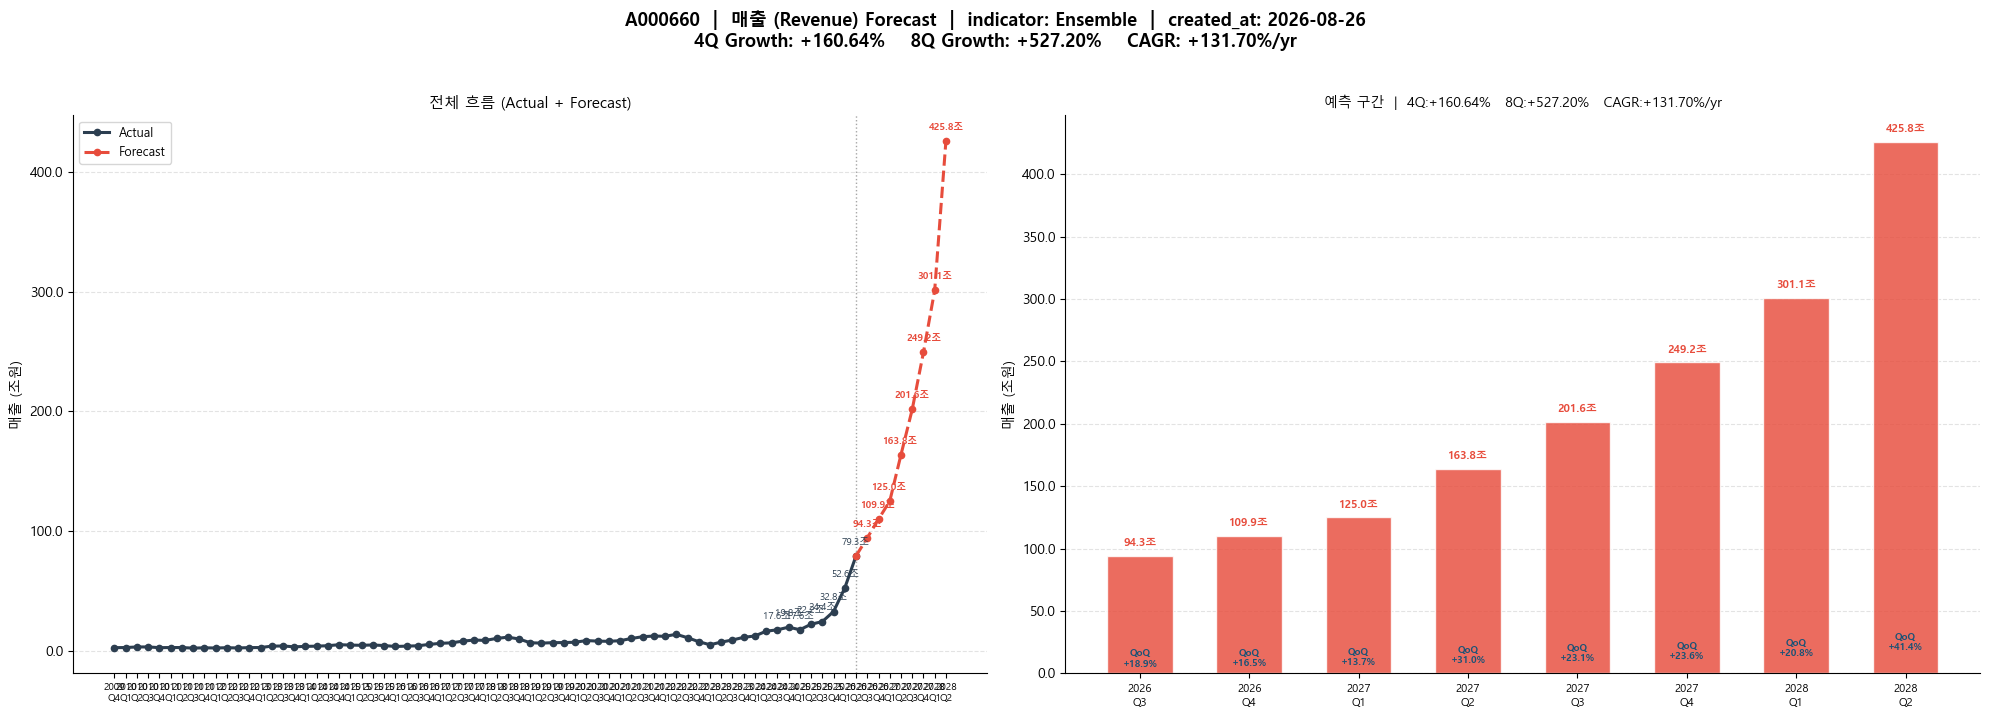

In [12]:
CHART_TICKER = "A000660"     # ← 변경 (예: A000660 SK하이닉스, A035420 NAVER 등)
CHART_MODEL  = "Ensemble"    # ← 변경

plot_ticker_forecast(CHART_TICKER, CHART_MODEL)


## Cell 11 · Best-N 성장률 비교 막대 차트

**위 패널** : 향후 4분기 누적 성장률  
**아래 패널** : 향후 8분기 누적 성장률  
각 막대마다 성장률(%) 값이 표시됩니다.


In [13]:
def plot_best_n_growth(
    best_df: pd.DataFrame,
    model: str,
    forecast_date,
    top_n: int = None,
    w_per_bar: float = 0.72,
):
    '''Best-N 기업의 4Q / 8Q 성장률 상하 2패널 비교 차트'''
    df = best_df.head(top_n).copy() if top_n else best_df.copy()
    tickers = df["ticker"].tolist()
    n       = len(tickers)
    if n == 0:
        print("[WARN] best_df 가 비어있습니다.")
        return
    colors  = (BAR_PALETTE * (n // len(BAR_PALETTE) + 1))[:n]

    has_4q = df["growth_4q_pct"].notna().any()
    has_8q = df["growth_8q_pct"].notna().any()
    n_pnl  = int(has_4q) + int(has_8q)
    if n_pnl == 0:
        print("[WARN] 성장률 데이터가 없습니다.")
        return

    figw  = max(14, n * w_per_bar)
    fig, axes = plt.subplots(n_pnl, 1, figsize=(figw, 5.5 * n_pnl))
    if n_pnl == 1:
        axes = [axes]

    if isinstance(forecast_date, (list, tuple)):
        fd_str = ", ".join(str(d) for d in forecast_date)
    else:
        fd_str = str(forecast_date)

    fig.suptitle(
        f"한국 매출 성장률 Best-{n}  |  indicator: {model}  |  created_at: {fd_str}\n"
        "4Q: 예측4Q합÷실제직전4Q합−1   "
        "8Q: 예측8Q합÷실제최근8Q합−1",
        fontsize=13, fontweight="bold"
    )

    def _draw(ax, raw_vals, title):
        vals = [v if (v is not None and v == v and np.isfinite(v)) else 0
                for v in raw_vals]
        mx   = max(abs(v) for v in vals) if vals else 1

        bars = ax.bar(range(n), vals, color=colors,
                      alpha=0.88, width=0.65, edgecolor="white", zorder=2)

        for bar, v, orig in zip(bars, vals, raw_vals):
            if orig is None or orig != orig or (not np.isfinite(orig)):
                continue
            offset = mx * 0.025
            ypos   = bar.get_height() + (offset if v >= 0 else -offset * 3.8)
            va     = "bottom" if v >= 0 else "top"
            ax.text(
                bar.get_x() + bar.get_width() / 2, ypos,
                f"{v:+.1f}%",
                ha="center", va=va, fontsize=8.5,
                fontweight="bold",
                color="#1A5276" if v >= 0 else "#922B21"
            )

        ax.axhline(0, color="gray", lw=0.9, ls="--", alpha=0.55)
        ax.set_xticks(range(n))
        ax.set_xticklabels(tickers, rotation=40, ha="right", fontsize=9)
        ax.set_ylabel("성장률 (%)", fontsize=10)
        ax.set_title(title, fontsize=12, fontweight="bold", pad=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        ax.grid(axis="y", ls="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    pi = 0
    if has_4q:
        _draw(axes[pi], df["growth_4q_pct"].tolist(),
              "향후 4분기 누적 성장률  (예측 4Q합 / 실제 직전 4Q합 − 1)")
        pi += 1
    if has_8q:
        _draw(axes[pi], df["growth_8q_pct"].tolist(),
              "향후 8분기 누적 성장률  (예측 8Q합 / 실제 최근 8Q합 − 1)")

    plt.tight_layout()
    plt.show()


print("[OK] plot_best_n_growth 함수 정의 완료")


[OK] plot_best_n_growth 함수 정의 완료


### Cell 11 실행

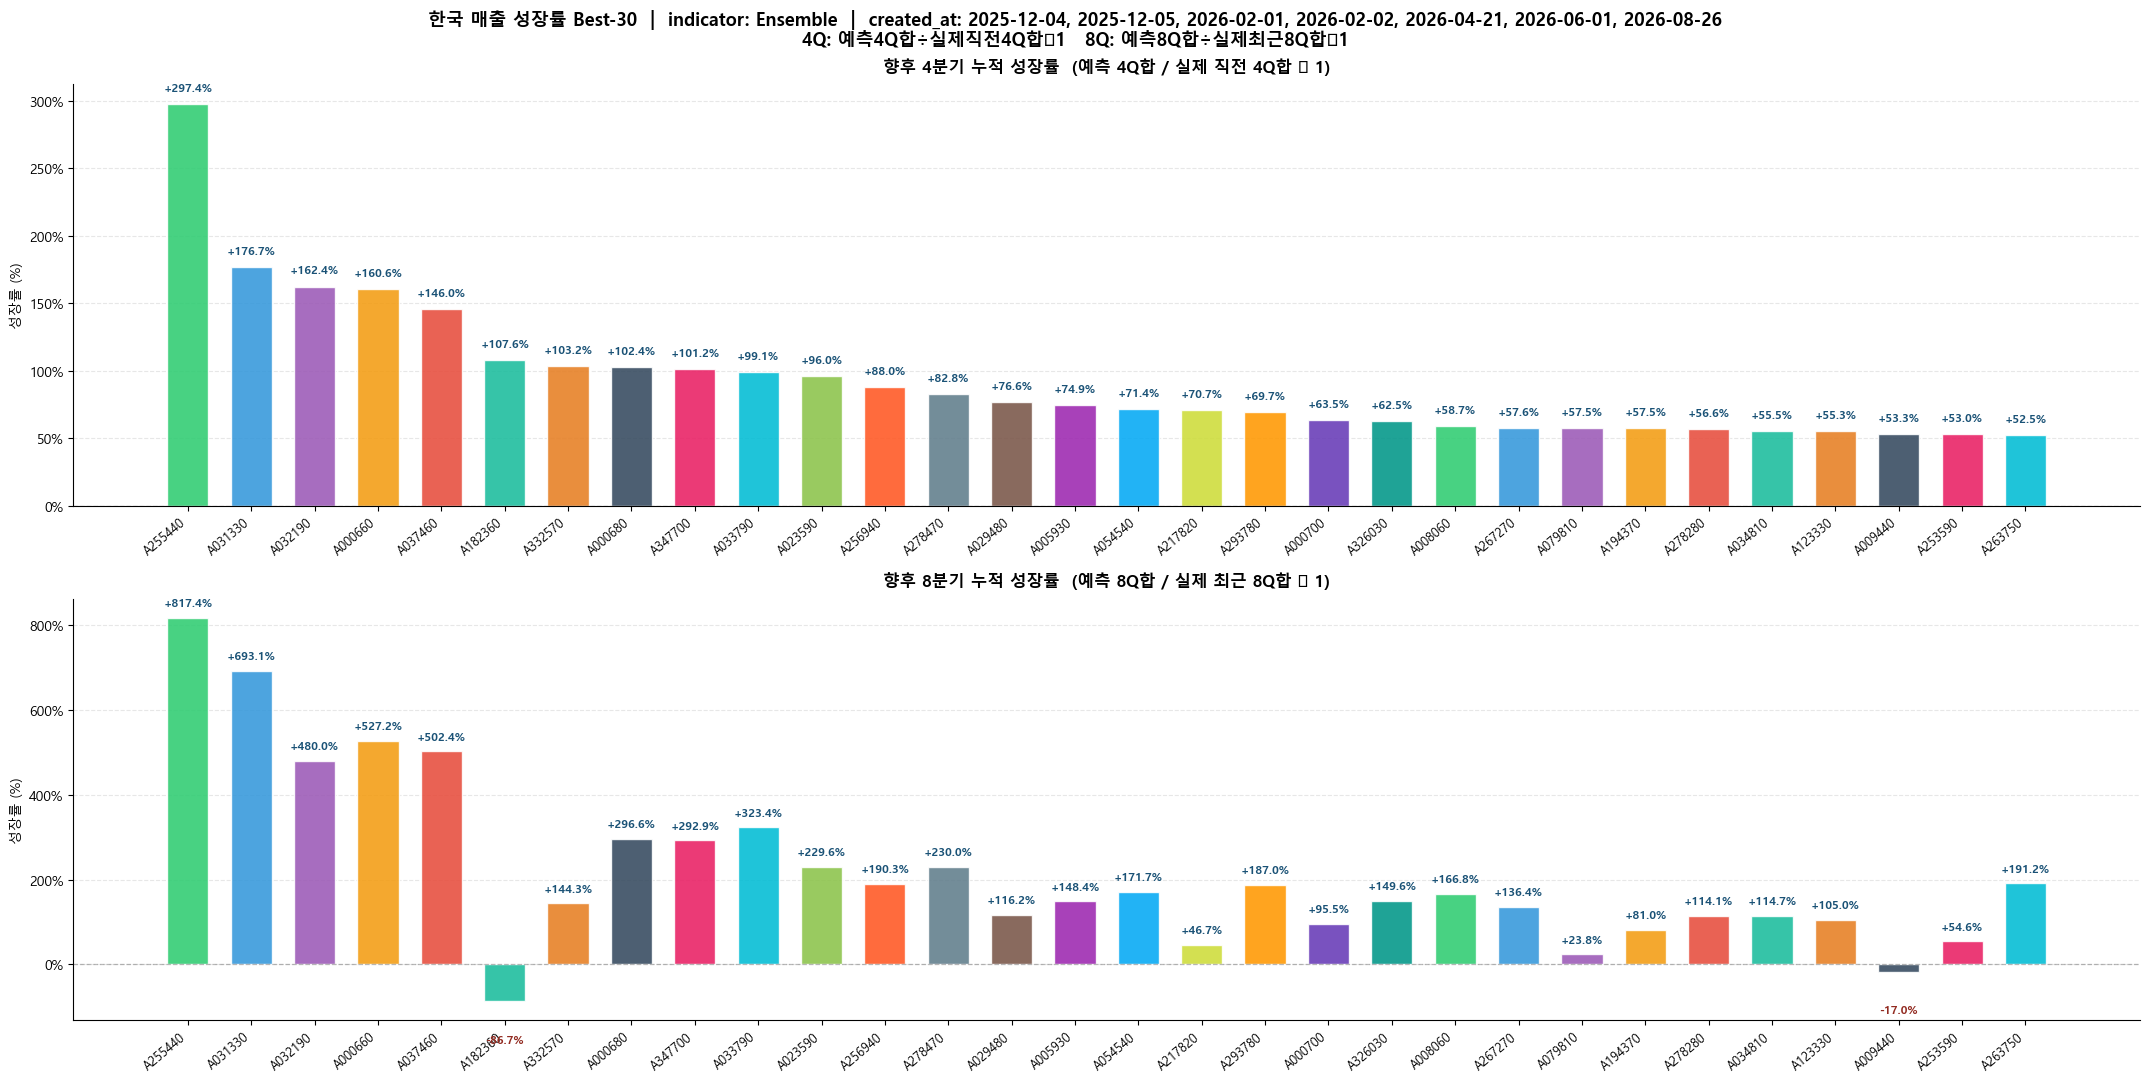

In [14]:
# Cell 8 에서 구한 best_df / used_fd 를 그대로 사용합니다.
# top_n 지정 시 상위 N개만 표시 (None → 전체)
plot_best_n_growth(
    best_df       = best_df,
    model         = BEST_MODEL,
    forecast_date = used_fd,
    top_n         = 30,    # 기본 30개만 표시 (None → 전체 BEST_N)
)


## Cell 12 · 전종목 매출 성장률 테이블 추출 & Excel 저장 (v4 신규)

Cell 8 의 Best-N 과 달리 **발산 종목을 제외한 전 종목**을 wide 포맷으로 뽑아 Excel 로 저장합니다.

```
ticker | company_name | forecast_date | revenue_ttm | Q+1 | Q+2 | Q+3 | Q+4 | revenue_forecast_sum | yoy_growth
```

- 단위: 기본 **억원** (`EXPORT_UNIT_DIVISOR = 1e5`). 원본 천원 그대로 저장하려면 `1` 로 변경
- `yoy_growth` 는 % 단위 (예: `12.34` = +12.34%)
- `forecast_date` 가 종목별로 다르면 `Q+1` 이 가리키는 분기도 다를 수 있음 → 실행 로그와 `meta` 시트의 `Q+1 period` 분포로 확인
- 발산 판별은 Cell 3 의 `MAX_GROWTH_PCT` / `MAX_FC_RATIO` 를 그대로 재사용
- 파일명: `revenue_growth_forecast_{model}_{YYYYMMDD}.xlsx` (같은 날 재실행 시 `_1`, `_2` … 자동 부여, 덮어쓰기 없음)


In [15]:
# ══════════════════════════════════════════════════════════════════════
# [v4 신규] 전종목 매출 성장률 테이블 추출 & Excel 저장
# ══════════════════════════════════════════════════════════════════════
# 출력 스키마 (시트 'growth')
#   ticker | forecast_date | revenue_ttm | Q+1 | Q+2 | Q+3 | Q+4
#          | revenue_forecast_sum | yoy_growth
#
#   revenue_ttm          : 직전 실제 4분기 매출 합산 (TTM)
#   Q+1 ~ Q+4            : 향후 4분기 예측 매출 (예측 시작 분기 순)
#   revenue_forecast_sum : Q+1 ~ Q+4 합산
#   yoy_growth           : revenue_forecast_sum / revenue_ttm − 1  (%)
#                          → Cell 7 의 growth_4q_pct 와 동일한 정의
#
# 부속 시트
#   'excluded' : 제외 종목 + 사유 (발산 / 데이터 부족 등)
#   'meta'     : 추출 파라미터 · Q+1 분기 분포 · 실행 버전 날짜
# ══════════════════════════════════════════════════════════════════════
from typing import Optional, Union, List, Tuple, Dict
from datetime import datetime

# ── Control Panel ────────────────────────────────────────────────────
EXPORT_MODEL           = "Ensemble"     # 예측 모델 indicator: SARIMA / ETS / Theta / Ensemble
EXPORT_FORECAST_DATE   = None           # None → 종목별 최신 실행 버전 / "2026-08-15" / ["2026-05-29", "2026-08-15"]
EXPORT_EXCLUDE_ANOMALY = True           # True → 발산 의심 종목(MAX_GROWTH_PCT / MAX_FC_RATIO 초과) 을 growth 시트에서 제외
EXPORT_UNIT_DIVISOR    = 1e5            # 금액 단위: 1 → 천원(원본 그대로), 1e5 → 억원
EXPORT_UNIT_LABEL      = "억원"          # 위 divisor 에 맞는 단위 표기 (meta 시트 기록용)
EXPORT_INCLUDE_NAME    = True           # True → company_name 컬럼을 ticker 오른쪽에 추가 (유튜브 자료용)
EXPORT_SORT_BY         = "yoy_growth"   # 정렬 컬럼 ("yoy_growth" / "revenue_ttm" / "revenue_forecast_sum" / "ticker")
EXPORT_SORT_ASC        = False          # 정렬 방향 (False → 내림차순)
EXPORT_FILE_PREFIX     = "revenue_growth_forecast"   # 파일명 접두어 → {prefix}_{model}_{YYYYMMDD}.xlsx

# 저장 폴더: 데스크탑 / 노트북 자동 감지 (상위 폴더가 존재하는 첫 후보 사용)
EXPORT_DIR_CANDIDATES = [
    r"C:\Users\82108\OneDrive\INVESTMENT\한국주식\2026_매출성장예측",          # 데스크탑
    r"C:\Users\Hoyoung_Park\OneDrive\INVESTMENT\한국주식\2026_매출성장예측",   # 노트북
]
# ─────────────────────────────────────────────────────────────────────


def _resolve_export_dir(candidates: List[str]) -> str:
    '''후보 경로 중 (폴더 자체 또는 상위 폴더가) 존재하는 첫 경로를 반환. 없으면 생성.'''
    for d in candidates:
        if os.path.isdir(d):
            return d
        if os.path.isdir(os.path.dirname(d)):
            os.makedirs(d, exist_ok=True)
            print(f"[INFO] 저장 폴더 생성: {d}")
            return d
    raise EnvironmentError(
        "저장 폴더를 찾을 수 없습니다. EXPORT_DIR_CANDIDATES 를 확인하세요."
    )


def _unique_path(path: str) -> str:
    '''같은 이름의 파일이 이미 있으면 _1, _2 … 접미어를 붙여 덮어쓰기 방지.'''
    if not os.path.exists(path):
        return path
    stem, ext = os.path.splitext(path)
    k = 1
    while os.path.exists(f"{stem}_{k}{ext}"):
        k += 1
    return f"{stem}_{k}{ext}"


def _load_forecast_and_actual(
    model: str,
    forecast_date: Optional[Union[str, List[str]]] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    '''
    get_best_n 의 조회 로직(1·2단계)을 그대로 분리한 헬퍼.
    Returns: (fc_all, act_all, used_dates)
      fc_all  : ticker, date, value, run_ts   (종목별 최신 실행 버전, (ticker,date) 중복 제거)
      act_all : ticker, date, value           (분기 중복 제거)
    '''
    rc = RECENCY_COL

    if forecast_date is None:
        sql_fc = (
            f"SELECT f.ticker, f.date, f.value, f.{rc} AS run_ts "
            f"FROM {FORECAST_TABLE} f "
            f"JOIN ( "
            f"    SELECT ticker, MAX(DATE({rc})) AS max_rd "
            f"    FROM {FORECAST_TABLE} WHERE indicator=:m GROUP BY ticker "
            f") g ON f.ticker = g.ticker AND DATE(f.{rc}) = g.max_rd "
            f"WHERE f.indicator=:m "
            f"ORDER BY f.ticker, f.date"
        )
        params: Dict[str, str] = {"m": model}
    else:
        if isinstance(forecast_date, str):
            date_list = [forecast_date[:10]]
        else:
            date_list = [str(d)[:10] for d in forecast_date]
        if not date_list:
            raise ValueError("forecast_date 가 빈 리스트입니다.")
        in_clause = ", ".join(f"'{d}'" for d in date_list)
        sql_fc = (
            f"SELECT ticker, date, value, {rc} AS run_ts "
            f"FROM {FORECAST_TABLE} "
            f"WHERE indicator=:m AND DATE({rc}) IN ({in_clause}) "
            f"ORDER BY ticker, {rc} DESC, date"
        )
        params = {"m": model}

    with engine.connect() as conn:
        fc_all = pd.read_sql(text(sql_fc), conn, params=params)
    if fc_all.empty:
        raise ValueError(f"indicator='{model}' 예측 데이터가 없습니다.")

    fc_all["date"]   = pd.to_datetime(fc_all["date"])
    fc_all["run_ts"] = pd.to_datetime(fc_all["run_ts"])
    fc_all["value"]  = fc_all["value"].astype(float)
    fc_all = (fc_all.sort_values(["ticker", "date", "run_ts"])
                    .drop_duplicates(subset=["ticker", "date"], keep="last")
                    .reset_index(drop=True))
    used_dates = sorted(fc_all["run_ts"].dt.strftime("%Y-%m-%d").unique().tolist())

    # ── actual 조회 (chunked) ──
    tickers = fc_all["ticker"].unique().tolist()
    CHUNK = 1000
    parts = []
    sql_act_tmpl = (
        "SELECT ticker, date, value FROM {tbl} "
        "WHERE item_code=:ic AND value IS NOT NULL "
        "  AND ticker IN ({tk_list}) "
        "ORDER BY ticker, date"
    )
    with engine.connect() as conn:
        for i in range(0, len(tickers), CHUNK):
            tk_list = ", ".join(f"'{t}'" for t in tickers[i:i + CHUNK])
            parts.append(pd.read_sql(
                text(sql_act_tmpl.format(tbl=FS_TABLE, tk_list=tk_list)),
                conn, params={"ic": REVENUE_ITEM_CODE},
            ))
    act_all = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(
        columns=["ticker", "date", "value"])
    if not act_all.empty:
        act_all["date"]  = pd.to_datetime(act_all["date"])
        act_all["value"] = act_all["value"].astype(float)
        act_all = (act_all.assign(period=act_all["date"].dt.to_period("Q"))
                          .sort_values(["ticker", "period", "date"])
                          .drop_duplicates(subset=["ticker", "period"], keep="last")
                          .drop(columns=["period"])
                          .reset_index(drop=True))
    return fc_all, act_all, used_dates


def _load_company_names(tickers: List[str]) -> Dict[str, str]:
    '''korea_fs_data_from_DG 에서 ticker → company_name (가장 최근 값) 매핑.'''
    names: Dict[str, str] = {}
    CHUNK = 1000
    sql_tmpl = (
        "SELECT ticker, company_name FROM {tbl} "
        "WHERE ticker IN ({tk_list}) AND company_name IS NOT NULL "
        "GROUP BY ticker, company_name"
    )
    with engine.connect() as conn:
        for i in range(0, len(tickers), CHUNK):
            tk_list = ", ".join(f"'{t}'" for t in tickers[i:i + CHUNK])
            part = pd.read_sql(text(sql_tmpl.format(tbl=FS_TABLE, tk_list=tk_list)), conn)
            for t, nm in zip(part["ticker"], part["company_name"]):
                names[t] = nm      # 동일 ticker 복수 이름이면 마지막 값 유지
    return names


def build_revenue_growth_table(
    model: str = EXPORT_MODEL,
    forecast_date: Optional[Union[str, List[str]]] = EXPORT_FORECAST_DATE,
    exclude_anomaly: bool = EXPORT_EXCLUDE_ANOMALY,
    unit_divisor: float = EXPORT_UNIT_DIVISOR,
    include_name: bool = EXPORT_INCLUDE_NAME,
    sort_by: str = EXPORT_SORT_BY,
    ascending: bool = EXPORT_SORT_ASC,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    '''
    전종목 매출 성장률 wide 테이블 생성.

    Returns: (growth_df, excluded_df, meta_df)
      growth_df   : ticker | [company_name] | forecast_date | revenue_ttm | Q+1..Q+4
                    | revenue_forecast_sum | yoy_growth(%)
      excluded_df : 제외 종목 (ticker, forecast_date, reason, yoy_growth_raw)
      meta_df     : 추출 파라미터 및 Q+1 분기 분포
    '''
    fc_all, act_all, used_dates = _load_forecast_and_actual(model, forecast_date)
    print(f"[INFO] indicator={model}  실행 버전 날짜={used_dates}  "
          f"조회 ticker 수={fc_all['ticker'].nunique()}")

    act_dict = {t: g for t, g in act_all.groupby("ticker")} if not act_all.empty else {}

    rows: List[dict] = []
    excluded: List[dict] = []
    q1_periods: List[str] = []

    for ticker, fc_grp in fc_all.groupby("ticker", sort=True):
        fc_grp = fc_grp.sort_values("date")
        run_date = fc_grp["run_ts"].max().strftime("%Y-%m-%d")
        fc_first = fc_grp["date"].min()

        def _skip(reason: str, yoy_raw: Optional[float] = None) -> None:
            excluded.append({"ticker": ticker, "forecast_date": run_date,
                             "reason": reason, "yoy_growth_raw": yoy_raw})

        act_grp = act_dict.get(ticker)
        if act_grp is None or act_grp.empty:
            _skip("실제 매출 데이터 없음"); continue
        act_grp = act_grp[act_grp["date"] < fc_first]
        act_vals = act_grp["value"].tolist()
        if len(act_vals) < 4:
            _skip(f"실제 분기 수 부족 ({len(act_vals)} < 4)"); continue

        fc_vals = fc_grp["value"].tolist()
        if len(fc_vals) < 4:
            _skip(f"예측 분기 수 부족 ({len(fc_vals)} < 4)"); continue
        fc4 = fc_vals[:4]
        if not np.all(np.isfinite(fc4)):
            _skip("예측값에 NaN/inf 포함"); continue

        ttm  = float(sum(act_vals[-4:]))
        fsum = float(sum(fc4))
        if ttm <= 0 or not np.isfinite(ttm):
            _skip("TTM 매출 ≤ 0 또는 비유한값"); continue
        yoy = (fsum / ttm - 1.0) * 100.0

        # ── 발산 판별 (Cell 3 임계값 재사용) ──
        anomaly_reason: Optional[str] = None
        if abs(yoy) > MAX_GROWTH_PCT:
            anomaly_reason = f"|yoy_growth| > {MAX_GROWTH_PCT}%"
        elif fsum / ttm > MAX_FC_RATIO:
            anomaly_reason = f"예측4Q합/TTM > {MAX_FC_RATIO}배"
        if anomaly_reason is not None and exclude_anomaly:
            _skip(f"발산 의심: {anomaly_reason}", round(yoy, 2)); continue

        q1_periods.append(str(fc_first.to_period("Q")))
        rows.append({
            "ticker"              : ticker,
            "forecast_date"       : run_date,
            "revenue_ttm"         : round(ttm / unit_divisor, 2),
            "Q+1"                 : round(fc4[0] / unit_divisor, 2),
            "Q+2"                 : round(fc4[1] / unit_divisor, 2),
            "Q+3"                 : round(fc4[2] / unit_divisor, 2),
            "Q+4"                 : round(fc4[3] / unit_divisor, 2),
            "revenue_forecast_sum": round(fsum / unit_divisor, 2),
            "yoy_growth"          : round(yoy, 2),
        })

    growth_df   = pd.DataFrame(rows)
    excluded_df = pd.DataFrame(excluded, columns=["ticker", "forecast_date", "reason", "yoy_growth_raw"])

    # ── company_name 추가 (옵션) ──
    if include_name and not growth_df.empty:
        name_map = _load_company_names(growth_df["ticker"].tolist())
        growth_df.insert(1, "company_name", growth_df["ticker"].map(name_map))

    # ── 정렬 ──
    if not growth_df.empty and sort_by in growth_df.columns:
        growth_df = (growth_df.sort_values(sort_by, ascending=ascending, na_position="last")
                              .reset_index(drop=True))

    # ── meta ──
    q1_dist = pd.Series(q1_periods).value_counts().sort_index() if q1_periods else pd.Series(dtype=int)
    meta_rows = [
        ("extract_datetime",  datetime.now().strftime("%Y-%m-%d %H:%M:%S")),
        ("model",             model),
        ("forecast_date_arg", "auto(latest per ticker)" if forecast_date is None else str(forecast_date)),
        ("used_run_dates",    ", ".join(used_dates)),
        ("unit",              f"{EXPORT_UNIT_LABEL} (원본 천원 ÷ {unit_divisor:g})"),
        ("yoy_growth_def",    "(Q+1..Q+4 합) / (직전 실제 4Q 합) − 1, 단위 %"),
        ("exclude_anomaly",   str(exclude_anomaly)),
        ("MAX_GROWTH_PCT",    str(MAX_GROWTH_PCT)),
        ("MAX_FC_RATIO",      str(MAX_FC_RATIO)),
        ("n_included",        str(len(growth_df))),
        ("n_excluded",        str(len(excluded_df))),
    ] + [(f"Q+1 period = {p}", str(int(c))) for p, c in q1_dist.items()]
    meta_df = pd.DataFrame(meta_rows, columns=["key", "value"])

    print(f"[INFO] 포함 {len(growth_df)}개 / 제외 {len(excluded_df)}개")
    if len(q1_dist) > 1:
        print(f"[주의] Q+1 이 종목별로 다른 분기를 가리킵니다 → meta 시트 확인:")
        print(q1_dist.to_string())
    elif len(q1_dist) == 1:
        print(f"[INFO] Q+1 = {q1_dist.index[0]} (전 종목 동일)")
    return growth_df, excluded_df, meta_df


def export_revenue_growth_excel(
    growth_df: pd.DataFrame,
    excluded_df: pd.DataFrame,
    meta_df: pd.DataFrame,
    model: str = EXPORT_MODEL,
    export_dir: Optional[str] = None,
    file_prefix: str = EXPORT_FILE_PREFIX,
) -> str:
    '''
    3개 시트(growth / excluded / meta)를 하나의 Excel 로 저장.
    파일명: {file_prefix}_{model}_{YYYYMMDD}.xlsx  (같은 날 재실행 시 _1, _2 … 자동 부여)
    Returns: 저장된 파일 경로
    '''
    out_dir = export_dir if export_dir is not None else _resolve_export_dir(EXPORT_DIR_CANDIDATES)
    today   = datetime.now().strftime("%Y%m%d")
    path    = _unique_path(os.path.join(out_dir, f"{file_prefix}_{model}_{today}.xlsx"))

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        growth_df.to_excel(writer,   sheet_name="growth",   index=False)
        excluded_df.to_excel(writer, sheet_name="excluded", index=False)
        meta_df.to_excel(writer,     sheet_name="meta",     index=False)

        # 열 폭 자동 조정 + growth 시트 숫자 서식 + 헤더 고정
        for sh_name, df in (("growth", growth_df), ("excluded", excluded_df), ("meta", meta_df)):
            ws = writer.sheets[sh_name]
            ws.freeze_panes = "A2"
            for j, col in enumerate(df.columns, start=1):
                width = max([len(str(col))] + [len(str(v)) for v in df[col].head(300)]) + 2
                ws.column_dimensions[ws.cell(row=1, column=j).column_letter].width = min(max(width, 8), 40)
        ws = writer.sheets["growth"]
        for j, col in enumerate(growth_df.columns, start=1):
            if col == "yoy_growth":
                fmt = '0.00"%"'
            elif col in ("revenue_ttm", "Q+1", "Q+2", "Q+3", "Q+4", "revenue_forecast_sum"):
                fmt = "#,##0.00"
            else:
                continue
            for cell in ws.iter_cols(min_col=j, max_col=j, min_row=2, max_row=ws.max_row):
                for c in cell:
                    c.number_format = fmt

    print(f"[OK] Excel 저장 완료 → {path}")
    print(f"     시트: growth({len(growth_df)}행) / excluded({len(excluded_df)}행) / meta({len(meta_df)}행)")
    return path


print("[OK] v4 함수 정의 완료: build_revenue_growth_table / export_revenue_growth_excel")
print(f"     EXPORT_MODEL={EXPORT_MODEL}  단위={EXPORT_UNIT_LABEL}  발산 제외={EXPORT_EXCLUDE_ANOMALY}  "
      f"company_name 포함={EXPORT_INCLUDE_NAME}")


[OK] v4 함수 정의 완료: build_revenue_growth_table / export_revenue_growth_excel
     EXPORT_MODEL=Ensemble  단위=억원  발산 제외=True  company_name 포함=True


### Cell 12 실행

위 Control Panel 값을 그대로 사용해 테이블 생성 → Excel 저장 → 상위 30개 미리보기.

In [16]:
# ── 실행 (정확히 1회) ──────────────────────────────────────────────
growth_df, excluded_df, meta_df = build_revenue_growth_table()

saved_path = export_revenue_growth_excel(growth_df, excluded_df, meta_df)

# ── 미리보기 (상위 30개) ───────────────────────────────────────────
PREVIEW_N = 30
_num_cols = ["revenue_ttm", "Q+1", "Q+2", "Q+3", "Q+4", "revenue_forecast_sum"]
print(f"\n[매출 성장률 전종목 추출]  model={EXPORT_MODEL}  단위={EXPORT_UNIT_LABEL}  "
      f"포함 {len(growth_df)}개 / 제외 {len(excluded_df)}개")
display(
    growth_df.head(PREVIEW_N).style
    .format({**{c: "{:,.1f}" for c in _num_cols}, "yoy_growth": "{:+.2f}%"}, na_rep="-")
    .background_gradient(subset=["yoy_growth"], cmap="YlGn")
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("padding", "6px 10px"),
                                      ("font-weight", "bold"), ("background-color", "#34495E"),
                                      ("color", "white")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "6px 10px"),
                                      ("max-width", "150px"), ("white-space", "nowrap")]},
    ])
    .set_caption(f"전종목 매출 성장률 Top-{PREVIEW_N} 미리보기 (전체는 Excel 참조)  |  {saved_path}")
)

# ── 제외 사유 요약 ─────────────────────────────────────────────────
if len(excluded_df) > 0:
    print("\n── 제외 사유별 종목 수 ──")
    print(excluded_df["reason"].str.split(":").str[0].value_counts().to_string())


[INFO] indicator=Ensemble  실행 버전 날짜=['2025-12-04', '2025-12-05', '2026-02-01', '2026-02-02', '2026-04-21', '2026-06-01', '2026-08-26']  조회 ticker 수=3118
[INFO] 포함 1290개 / 제외 1828개
[주의] Q+1 이 종목별로 다른 분기를 가리킵니다 → meta 시트 확인:
2026Q1       1
2026Q2      31
2026Q3    1258
[OK] Excel 저장 완료 → C:\Users\82108\OneDrive\INVESTMENT\한국주식\2026_매출성장예측\revenue_growth_forecast_Ensemble_20260902.xlsx
     시트: growth(1290행) / excluded(1828행) / meta(14행)

[매출 성장률 전종목 추출]  model=Ensemble  단위=억원  포함 1290개 / 제외 1828개


,ticker,company_name,forecast_date,revenue_ttm,Q+1,Q+2,Q+3,Q+4,revenue_forecast_sum,yoy_growth
0,A255440,야스,2026-08-26,"1,444.5","1,047.0","1,323.1","1,549.4","1,821.4","5,740.8",+297.41%
1,A080220,제주반도체,2026-08-26,"6,731.3","3,551.6","3,499.0","6,249.6","11,263.0","24,563.2",+264.91%
2,A031330,에스에이엠티,2026-08-26,"64,500.6","30,648.4","36,796.6","49,345.2","61,678.0","178,468.1",+176.69%
3,A032190,다우데이타,2026-08-26,"354,545.3","156,884.6","201,914.4","265,134.9","306,327.6","930,261.5",+162.38%
4,A000660,SK하이닉스,2026-08-26,"1,891,706.1","943,482.5","1,099,462.2","1,249,918.0","1,637,659.8","4,930,522.5",+160.64%
5,A037460,삼지전자,2026-08-26,"69,391.1","30,816.5","35,926.3","46,757.3","57,227.1","170,727.2",+146.04%
6,A182360,큐브엔터,2026-08-26,273.6,231.5,40.6,87.5,208.4,568.0,+107.59%
7,A332570,PS일렉트로닉스,2026-08-26,"1,655.9",785.9,881.2,863.6,833.9,"3,364.5",+103.19%
8,A000680,LS네트웍스,2026-08-26,"57,058.4","21,498.8","28,734.2","28,810.9","36,428.3","115,472.2",+102.38%
9,A347700,스피어,2026-08-26,"1,770.6",775.9,814.6,880.2,"1,091.4","3,562.1",+101.18%



── 제외 사유별 종목 수 ──
reason
실제 매출 데이터 없음    1828


## Cell 13 · 연도(FY) 기준 YoY(t) / YoY(t+1) 성장률 (v5 신규)

```
Y-1  = FY(t−1) 실제 4분기 합                (전부 실제값)
Y0   = FY(t)   실제 발표 분기 + 예측 미발표 분기 합    ← "2A+2F" 처럼 구성 표시
Y+1  = FY(t+1) 예측 4분기 합

YoY(t)   = Y0  / Y-1 − 1
YoY(t+1) = Y+1 / Y0  − 1
```

- Cell 12 의 `yoy_growth` 는 **rolling** (직전 실제 4Q → 향후 예측 4Q), 이 셀은 **회계연도 고정** 비교
- `FY_BASE_YEAR=None` 이면 Q+1 이 속한 연도의 최빈값을 Y0 로 사용 (실행 로그에 분포 출력)
- 실적 발표 시차로 종목별 `Y0_mix` 가 다를 수 있음 (`2A+2F` vs `1A+3F`) → `last_actual_q` 로 확인
- 단위·저장 폴더는 Cell 12 설정(`EXPORT_UNIT_DIVISOR`, `EXPORT_DIR_CANDIDATES`) 재사용


In [17]:
# ══════════════════════════════════════════════════════════════════════
# [v5 신규] 연도(FY) 기준 YoY 매출 성장률  — 실제 + 예측 혼합 합산
# ══════════════════════════════════════════════════════════════════════
# 기존 Cell 12 는 "직전 실제 4Q(TTM)" vs "향후 예측 4Q" 의 rolling 비교.
# 이 셀은 회계연도(기본: 12월 결산 = 달력연도) 단위로 다음을 계산한다.
#
#   Y-1  = 직전 연도 매출  : 실제 4분기 합산            (전부 실제값이어야 함)
#   Y0   = 올해 매출      : 발표된 실제 분기 + 미발표 분기 예측값 합산
#          예) 2026 Q1·Q2 실제 + Q3·Q4 예측  →  Y0_mix = "2A+2F"
#   Y+1  = 내년 매출      : 4분기 예측 합산            (실제값이 있으면 실제 우선)
#
#   YoY(t)   = Y0  / Y-1 − 1   (%)   ← 올해 성장률
#   YoY(t+1) = Y+1 / Y0  − 1   (%)   ← 내년 성장률
#
# 분기 매핑 규칙
#   - 분기 키 = (회계연도, 회계분기) 로 정규화 → DataGuide 의 영업일 결산일
#     (예: 2025-12-30) 도 정상적으로 Q4 로 귀속됨.
#   - 같은 분기에 실제값과 예측값이 모두 있으면 **실제값 우선**.
#   - 각 연도는 4개 분기가 모두 채워져야 계산. 하나라도 없으면 제외(사유 기록).
#
# 출력 스키마 (시트 'fy_growth')
#   ticker | company_name | forecast_date | last_actual_q | base_year
#   | Y-1 | Y0 | Y+1 | yoy_t | yoy_t1 | Y0_mix
#   | Y0_Q1..Y0_Q4 | Y1_Q1..Y1_Q4                     (금액 단위: EXPORT_UNIT_DIVISOR)
# ══════════════════════════════════════════════════════════════════════
from typing import Optional, Union, List, Tuple, Dict

# ── Control Panel ────────────────────────────────────────────────────
FY_MODEL             = "Ensemble"   # 예측 모델 indicator: SARIMA / ETS / Theta / Ensemble
FY_FORECAST_DATE     = None         # None → 종목별 최신 실행 버전 / "2026-08-15" / [...]
FY_BASE_YEAR         = None         # None → 자동(Q+1 이 속한 회계연도의 최빈값) / 2026 등 정수로 고정
FY_END_MONTH         = 12           # 결산월. 12 → 달력연도 = 회계연도. (3월 결산이면 3)
FY_REQUIRE_FULL_ACTUAL_YM1 = True   # True → Y-1 은 4분기 모두 실제값일 때만 계산 (예측 섞이면 제외)
FY_EXCLUDE_ANOMALY   = True         # True → |yoy_t| 또는 |yoy_t1| > MAX_GROWTH_PCT 종목 제외
FY_INCLUDE_NAME      = True         # True → company_name 컬럼 추가
FY_SORT_BY           = "yoy_t1"     # 정렬 컬럼 ("yoy_t1" / "yoy_t" / "Y0" / "Y+1" / "ticker")
FY_SORT_ASC          = False        # False → 내림차순
FY_FILE_PREFIX       = "revenue_fy_growth"   # → {prefix}_{model}_{base_year}_{YYYYMMDD}.xlsx
# 단위·저장 폴더는 Cell 12 의 EXPORT_UNIT_DIVISOR / EXPORT_UNIT_LABEL / EXPORT_DIR_CANDIDATES 재사용
# ─────────────────────────────────────────────────────────────────────


def _fy_of(ts, fy_end_month: int = FY_END_MONTH) -> int:
    '''분기말 날짜 → 회계연도 (결산월이 속한 달력연도로 표기).'''
    return ts.year if ts.month <= fy_end_month else ts.year + 1


def _fq_of(ts, fy_end_month: int = FY_END_MONTH) -> int:
    '''분기말 날짜 → 회계분기 (1~4). 결산월 12 면 달력 분기와 동일.'''
    m = (ts.month - fy_end_month - 1) % 12      # 회계연도 시작 후 경과 월 (0~11)
    return m // 3 + 1


def _calc_fy_growth(
    act_grp: pd.DataFrame,
    fc_grp: pd.DataFrame,
    base_year: int,
    fy_end_month: int = FY_END_MONTH,
    require_full_actual_ym1: bool = FY_REQUIRE_FULL_ACTUAL_YM1,
) -> dict:
    '''
    단일 종목의 (Y-1, Y0, Y+1) 연간 매출 및 YoY(t), YoY(t+1) 계산.
    act_grp / fc_grp : columns [date, value]   (천원)
    반환 dict 의 'reason' 이 None 이면 정상, 아니면 제외 사유.
    '''
    # 1) 분기 맵 구성: (FY, FQ) → (value, 'A'|'F').  실제값이 예측값을 덮어씀.
    qmap: Dict[Tuple[int, int], Tuple[float, str]] = {}
    for dt, v in zip(fc_grp["date"], fc_grp["value"]):
        qmap[(_fy_of(dt, fy_end_month), _fq_of(dt, fy_end_month))] = (float(v), "F")
    for dt, v in zip(act_grp["date"], act_grp["value"]):
        qmap[(_fy_of(dt, fy_end_month), _fq_of(dt, fy_end_month))] = (float(v), "A")

    def _year(fy: int):
        '''해당 FY 의 4분기 (vals, srcs, total). 하나라도 없으면 (None, None, None).'''
        vals, srcs = [], []
        for q in (1, 2, 3, 4):
            item = qmap.get((fy, q))
            if item is None or not np.isfinite(item[0]):
                return None, None, None
            vals.append(item[0]); srcs.append(item[1])
        return vals, srcs, float(sum(vals))

    def _mix(srcs: Optional[List[str]]) -> Optional[str]:
        if srcs is None:
            return None
        na = srcs.count("A"); nf = 4 - na
        return f"{na}A+{nf}F"

    ym1_v, ym1_s, ym1 = _year(base_year - 1)
    y0_v,  y0_s,  y0  = _year(base_year)
    y1_v,  y1_s,  y1  = _year(base_year + 1)

    last_act = act_grp["date"].max() if not act_grp.empty else None
    last_act_q = (f"{_fy_of(last_act, fy_end_month)}Q{_fq_of(last_act, fy_end_month)}"
                  if last_act is not None else None)

    out = {
        "base_year"    : base_year,
        "last_actual_q": last_act_q,
        "Y-1": ym1, "Y0": y0, "Y+1": y1,
        "Ym1_mix": _mix(ym1_s), "Y0_mix": _mix(y0_s), "Y1_mix": _mix(y1_s),
        "Y0_q": y0_v, "Y1_q": y1_v, "Ym1_q": ym1_v,
        "yoy_t": None, "yoy_t1": None, "reason": None,
    }

    # 2) 결측/조건 검사
    if ym1 is None:
        out["reason"] = f"Y-1({base_year - 1}) 4분기 미완결"; return out
    if require_full_actual_ym1 and ym1_s.count("A") < 4:
        out["reason"] = f"Y-1({base_year - 1}) 에 예측값 포함 ({_mix(ym1_s)})"; return out
    if y0 is None:
        out["reason"] = f"Y0({base_year}) 4분기 미완결 (예측 구간 부족)"; return out
    if y1 is None:
        out["reason"] = f"Y+1({base_year + 1}) 4분기 미완결 (예측 구간 부족)"; return out
    if ym1 <= 0:
        out["reason"] = f"Y-1 매출 ≤ 0"; return out
    if y0 <= 0:
        out["reason"] = f"Y0 매출 ≤ 0"; return out

    out["yoy_t"]  = (y0 / ym1 - 1.0) * 100.0
    out["yoy_t1"] = (y1 / y0  - 1.0) * 100.0
    return out


def _resolve_base_year(fc_all: pd.DataFrame, fy_end_month: int = FY_END_MONTH) -> int:
    '''base_year 자동 결정: 종목별 Q+1(첫 예측 분기)이 속한 회계연도의 최빈값.'''
    first_dates = fc_all.groupby("ticker")["date"].min()
    fy_series   = first_dates.apply(lambda d: _fy_of(d, fy_end_month))
    dist        = fy_series.value_counts().sort_index()
    base_year   = int(dist.idxmax())
    print(f"[INFO] base_year 자동 결정 = {base_year}   (Q+1 회계연도 분포: "
          + ", ".join(f"{int(y)}:{int(c)}" for y, c in dist.items()) + ")")
    return base_year


def fetch_fy_growth(
    ticker: str,
    model: str = FY_MODEL,
    forecast_date: Optional[str] = None,
    base_year: Optional[int] = FY_BASE_YEAR,
) -> dict:
    '''
    단일 종목 연도별 YoY 조회 (Cell 6 스타일 점검용).
    fetch_forecast 결과를 재사용하며, 반환 dict 에 'year_table'(DataFrame) 포함.
    '''
    res = fetch_forecast(ticker, model, forecast_date)
    act, fc = res["actual_df"], res["forecast_df"]
    if base_year is None:
        base_year = _fy_of(fc["date"].min())
    r = _calc_fy_growth(act, fc, base_year)

    # 연도별 분기 상세 표 (long)
    rows = []
    for label, fy, vals, srcs in (
        ("Y-1", base_year - 1, r["Ym1_q"], None),
        ("Y0",  base_year,     r["Y0_q"],  None),
        ("Y+1", base_year + 1, r["Y1_q"],  None),
    ):
        mix = r[{"Y-1": "Ym1_mix", "Y0": "Y0_mix", "Y+1": "Y1_mix"}[label]]
        rows.append({
            "구분": label, "FY": fy,
            "Q1": vals[0] if vals else None, "Q2": vals[1] if vals else None,
            "Q3": vals[2] if vals else None, "Q4": vals[3] if vals else None,
            "연간합": r[label], "구성": mix,
        })
    r["year_table"]     = pd.DataFrame(rows)
    r["ticker"]         = res["ticker"]
    r["model"]          = model
    r["forecast_date"]  = res["forecast_date"]
    return r


def build_fy_growth_table(
    model: str = FY_MODEL,
    forecast_date: Optional[Union[str, List[str]]] = FY_FORECAST_DATE,
    base_year: Optional[int] = FY_BASE_YEAR,
    exclude_anomaly: bool = FY_EXCLUDE_ANOMALY,
    unit_divisor: float = EXPORT_UNIT_DIVISOR,
    include_name: bool = FY_INCLUDE_NAME,
    sort_by: str = FY_SORT_BY,
    ascending: bool = FY_SORT_ASC,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, int]:
    '''
    전종목 연도(FY) 기준 YoY 성장률 wide 테이블.

    Returns: (fy_df, excluded_df, meta_df, base_year)
      fy_df : ticker | [company_name] | forecast_date | last_actual_q | base_year
              | Y-1 | Y0 | Y+1 | yoy_t | yoy_t1 | Y0_mix | Y0_Q1..Q4 | Y1_Q1..Q4
    '''
    fc_all, act_all, used_dates = _load_forecast_and_actual(model, forecast_date)
    print(f"[INFO] indicator={model}  실행 버전 날짜={used_dates}  "
          f"조회 ticker 수={fc_all['ticker'].nunique()}")
    if base_year is None:
        base_year = _resolve_base_year(fc_all)
    else:
        print(f"[INFO] base_year 고정 = {base_year}")

    act_dict = {t: g for t, g in act_all.groupby("ticker")} if not act_all.empty else {}
    rows: List[dict] = []
    excluded: List[dict] = []
    mix_dist: List[str] = []

    for ticker, fc_grp in fc_all.groupby("ticker", sort=True):
        fc_grp   = fc_grp.sort_values("date")
        run_date = fc_grp["run_ts"].max().strftime("%Y-%m-%d")
        act_grp  = act_dict.get(ticker)
        if act_grp is None or act_grp.empty:
            excluded.append({"ticker": ticker, "forecast_date": run_date,
                             "reason": "실제 매출 데이터 없음",
                             "yoy_t_raw": None, "yoy_t1_raw": None})
            continue

        r = _calc_fy_growth(act_grp, fc_grp, base_year)
        if r["reason"] is not None:
            excluded.append({"ticker": ticker, "forecast_date": run_date,
                             "reason": r["reason"], "yoy_t_raw": None, "yoy_t1_raw": None})
            continue

        # ── 발산 판별 (Cell 3 임계값 재사용) ──
        if exclude_anomaly and (abs(r["yoy_t"]) > MAX_GROWTH_PCT or abs(r["yoy_t1"]) > MAX_GROWTH_PCT):
            excluded.append({"ticker": ticker, "forecast_date": run_date,
                             "reason": f"발산 의심: |yoy| > {MAX_GROWTH_PCT}%",
                             "yoy_t_raw": round(r["yoy_t"], 2), "yoy_t1_raw": round(r["yoy_t1"], 2)})
            continue

        mix_dist.append(r["Y0_mix"])
        row = {
            "ticker"       : ticker,
            "forecast_date": run_date,
            "last_actual_q": r["last_actual_q"],
            "base_year"    : base_year,
            "Y-1"          : round(r["Y-1"] / unit_divisor, 2),
            "Y0"           : round(r["Y0"]  / unit_divisor, 2),
            "Y+1"          : round(r["Y+1"] / unit_divisor, 2),
            "yoy_t"        : round(r["yoy_t"],  2),
            "yoy_t1"       : round(r["yoy_t1"], 2),
            "Y0_mix"       : r["Y0_mix"],
        }
        for q in range(4):
            row[f"Y0_Q{q + 1}"] = round(r["Y0_q"][q] / unit_divisor, 2)
        for q in range(4):
            row[f"Y1_Q{q + 1}"] = round(r["Y1_q"][q] / unit_divisor, 2)
        rows.append(row)

    fy_df       = pd.DataFrame(rows)
    excluded_df = pd.DataFrame(
        excluded, columns=["ticker", "forecast_date", "reason", "yoy_t_raw", "yoy_t1_raw"])

    if include_name and not fy_df.empty:
        name_map = _load_company_names(fy_df["ticker"].tolist())
        fy_df.insert(1, "company_name", fy_df["ticker"].map(name_map))

    if not fy_df.empty and sort_by in fy_df.columns:
        fy_df = (fy_df.sort_values(sort_by, ascending=ascending, na_position="last")
                      .reset_index(drop=True))

    mix_cnt = pd.Series(mix_dist).value_counts().sort_index() if mix_dist else pd.Series(dtype=int)
    meta_rows = [
        ("extract_datetime",  datetime.now().strftime("%Y-%m-%d %H:%M:%S")),
        ("model",             model),
        ("forecast_date_arg", "auto(latest per ticker)" if forecast_date is None else str(forecast_date)),
        ("used_run_dates",    ", ".join(used_dates)),
        ("base_year (Y0)",    str(base_year)),
        ("FY_END_MONTH",      str(FY_END_MONTH)),
        ("unit",              f"{EXPORT_UNIT_LABEL} (원본 천원 ÷ {unit_divisor:g})"),
        ("Y-1 def",           f"FY{base_year - 1} 실제 4분기 합"),
        ("Y0 def",            f"FY{base_year} 실제(발표분) + 예측(미발표분) 4분기 합"),
        ("Y+1 def",           f"FY{base_year + 1} 예측 4분기 합 (실제값 있으면 실제 우선)"),
        ("yoy_t def",         "Y0 / Y-1 − 1  (%)"),
        ("yoy_t1 def",        "Y+1 / Y0 − 1  (%)"),
        ("Y0_mix def",        "Y0 구성: nA+mF = 실제 n분기 + 예측 m분기"),
        ("require_full_actual_Y-1", str(FY_REQUIRE_FULL_ACTUAL_YM1)),
        ("exclude_anomaly",   str(exclude_anomaly)),
        ("MAX_GROWTH_PCT",    str(MAX_GROWTH_PCT)),
        ("n_included",        str(len(fy_df))),
        ("n_excluded",        str(len(excluded_df))),
    ] + [(f"Y0_mix = {m}", str(int(c))) for m, c in mix_cnt.items()]
    meta_df = pd.DataFrame(meta_rows, columns=["key", "value"])

    print(f"[INFO] 포함 {len(fy_df)}개 / 제외 {len(excluded_df)}개")
    if len(mix_cnt) > 0:
        print("[INFO] Y0 구성 분포 (실제A / 예측F):")
        print(mix_cnt.to_string())
    if len(mix_cnt) > 1:
        print("[주의] Y0 구성이 종목별로 다릅니다 (실적 발표 시차) → last_actual_q / Y0_mix 컬럼 확인")
    return fy_df, excluded_df, meta_df, base_year


def export_fy_growth_excel(
    fy_df: pd.DataFrame,
    excluded_df: pd.DataFrame,
    meta_df: pd.DataFrame,
    base_year: int,
    model: str = FY_MODEL,
    export_dir: Optional[str] = None,
    file_prefix: str = FY_FILE_PREFIX,
) -> str:
    '''
    시트 fy_growth / excluded / meta 를 하나의 Excel 로 저장.
    파일명: {prefix}_{model}_{base_year}_{YYYYMMDD}.xlsx (동일 파일 존재 시 _1, _2 …)
    '''
    out_dir = export_dir if export_dir is not None else _resolve_export_dir(EXPORT_DIR_CANDIDATES)
    today   = datetime.now().strftime("%Y%m%d")
    path    = _unique_path(os.path.join(out_dir, f"{file_prefix}_{model}_{base_year}_{today}.xlsx"))

    money_cols = [c for c in fy_df.columns
                  if c in ("Y-1", "Y0", "Y+1") or c.startswith("Y0_Q") or c.startswith("Y1_Q")]
    pct_cols   = [c for c in ("yoy_t", "yoy_t1") if c in fy_df.columns]

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        fy_df.to_excel(writer,       sheet_name="fy_growth", index=False)
        excluded_df.to_excel(writer, sheet_name="excluded",  index=False)
        meta_df.to_excel(writer,     sheet_name="meta",      index=False)

        for sh_name, df in (("fy_growth", fy_df), ("excluded", excluded_df), ("meta", meta_df)):
            ws = writer.sheets[sh_name]
            ws.freeze_panes = "A2"
            for j, col in enumerate(df.columns, start=1):
                width = max([len(str(col))] + [len(str(v)) for v in df[col].head(300)]) + 2
                ws.column_dimensions[ws.cell(row=1, column=j).column_letter].width = min(max(width, 8), 40)

        ws = writer.sheets["fy_growth"]
        for j, col in enumerate(fy_df.columns, start=1):
            if col in pct_cols:
                fmt = '0.00"%"'
            elif col in money_cols:
                fmt = "#,##0.00"
            else:
                continue
            for cell in ws.iter_cols(min_col=j, max_col=j, min_row=2, max_row=ws.max_row):
                for c in cell:
                    c.number_format = fmt

    print(f"[OK] Excel 저장 완료 → {path}")
    print(f"     시트: fy_growth({len(fy_df)}행) / excluded({len(excluded_df)}행) / meta({len(meta_df)}행)")
    return path


def plot_fy_growth_top(
    fy_df: pd.DataFrame,
    top_n: int = 30,
    sort_by: str = FY_SORT_BY,
    w_per_bar: float = 0.75,
):
    '''상위 N 종목의 YoY(t) vs YoY(t+1) 그룹 막대 비교 차트.'''
    df = fy_df.sort_values(sort_by, ascending=False).head(top_n).copy()
    if df.empty:
        print("[WARN] fy_df 가 비어있습니다."); return
    n     = len(df)
    lbl   = [f"{t}\n{nm}" if isinstance(nm, str) else t
             for t, nm in zip(df["ticker"], df.get("company_name", [None] * n))]
    x     = np.arange(n)
    w     = 0.4
    by    = int(df["base_year"].iloc[0])

    fig, ax = plt.subplots(figsize=(max(14, n * w_per_bar), 6.5))
    b1 = ax.bar(x - w / 2, df["yoy_t"],  width=w, color=ACTUAL_COLOR,   alpha=0.85,
                label=f"YoY(t)   FY{by} / FY{by - 1} − 1")
    b2 = ax.bar(x + w / 2, df["yoy_t1"], width=w, color=FORECAST_COLOR, alpha=0.85,
                label=f"YoY(t+1) FY{by + 1} / FY{by} − 1")
    mx = np.nanmax(np.abs(np.r_[df["yoy_t"].values, df["yoy_t1"].values])) or 1.0
    for bars in (b1, b2):
        for bar in bars:
            v = bar.get_height()
            if not np.isfinite(v):
                continue
            ax.text(bar.get_x() + bar.get_width() / 2, v + (mx * 0.02 if v >= 0 else -mx * 0.06),
                    f"{v:+.0f}%", ha="center", va="bottom", fontsize=8)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(lbl, rotation=90, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(f"연도 기준 매출 성장률 Top-{n}  (정렬: {sort_by}, Y0 = FY{by} 실제+예측 혼합)",
                 fontsize=13, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout(); plt.show()


print("[OK] v5 함수 정의 완료: fetch_fy_growth / build_fy_growth_table / export_fy_growth_excel / plot_fy_growth_top")
print(f"     FY_MODEL={FY_MODEL}  FY_BASE_YEAR={'auto' if FY_BASE_YEAR is None else FY_BASE_YEAR}  "
      f"FY_END_MONTH={FY_END_MONTH}  발산 제외={FY_EXCLUDE_ANOMALY}")


[OK] v5 함수 정의 완료: fetch_fy_growth / build_fy_growth_table / export_fy_growth_excel / plot_fy_growth_top
     FY_MODEL=Ensemble  FY_BASE_YEAR=auto  FY_END_MONTH=12  발산 제외=True


### Cell 13-a · 단일 종목 점검

`FY_TEST_TICKER` 의 연도별 분기 구성(실제/예측)과 YoY(t), YoY(t+1) 을 확인합니다.


In [18]:
FY_TEST_TICKER = "A278470"     # ← 변경
FY_TEST_MODEL  = FY_MODEL

r = fetch_fy_growth(FY_TEST_TICKER, FY_TEST_MODEL, base_year=FY_BASE_YEAR)
div, unit = EXPORT_UNIT_DIVISOR, EXPORT_UNIT_LABEL

print("=" * 78)
print(f"  Ticker        : {r['ticker']}   Model: {r['model']}   forecast_date: {r['forecast_date']}")
print(f"  base_year(Y0) : {r['base_year']}   last_actual_q: {r['last_actual_q']}   Y0 구성: {r['Y0_mix']}")
if r["reason"] is not None:
    print(f"  [제외] {r['reason']}")
else:
    print(f"  YoY(t)   = Y0/Y-1 − 1 : {r['yoy_t']:+.2f}%")
    print(f"  YoY(t+1) = Y+1/Y0 − 1 : {r['yoy_t1']:+.2f}%")
print("-" * 78)

yt = r["year_table"].copy()
for c in ("Q1", "Q2", "Q3", "Q4", "연간합"):
    yt[c] = yt[c].map(lambda v: f"{v / div:,.1f}" if v is not None and np.isfinite(v) else "-")
print(f"  단위: {unit}")
print(yt.to_string(index=False))
print("=" * 78)


  Ticker        : A278470   Model: Ensemble   forecast_date: 2026-08-26
  base_year(Y0) : 2026   last_actual_q: 2026Q2   Y0 구성: 2A+2F
  YoY(t)   = Y0/Y-1 − 1 : +112.15%
  YoY(t+1) = Y+1/Y0 − 1 : +64.75%
------------------------------------------------------------------------------
  단위: 억원
 구분   FY       Q1       Q2       Q3       Q4      연간합    구성
Y-1 2025  2,660.3  3,277.3  3,859.4  5,476.3 15,273.4 4A+0F
 Y0 2026  5,933.6  7,675.3  8,175.1 10,618.7 32,402.7 2A+2F
Y+1 2027 10,939.4 12,204.6 13,207.3 17,033.2 53,384.5 0A+4F


### Cell 13-b · 전종목 실행 → Excel 저장 → 미리보기 → 차트

위 Control Panel 값을 그대로 사용합니다.


[INFO] indicator=Ensemble  실행 버전 날짜=['2025-12-04', '2025-12-05', '2026-02-01', '2026-02-02', '2026-04-21', '2026-06-01', '2026-08-26']  조회 ticker 수=3118
[INFO] base_year 자동 결정 = 2025   (Q+1 회계연도 분포: 2022:8, 2023:13, 2024:11, 2025:1778, 2026:1308)
[INFO] 포함 1286개 / 제외 1832개
[INFO] Y0 구성 분포 (실제A / 예측F):
4A+0F    1286
[OK] Excel 저장 완료 → C:\Users\82108\OneDrive\INVESTMENT\한국주식\2026_매출성장예측\revenue_fy_growth_Ensemble_2025_20260902.xlsx
     시트: fy_growth(1286행) / excluded(1832행) / meta(19행)

[연도 기준 매출 성장률]  model=Ensemble  Y-1=FY2024  Y0=FY2025  Y+1=FY2026  단위=억원  포함 1286개 / 제외 1832개


,ticker,company_name,forecast_date,last_actual_q,Y-1,Y0,Y+1,yoy_t,yoy_t1,Y0_mix
0,A255440,야스,2026-08-26,2026Q2,289.0,347.6,"3,568.8",+20.30%,+926.58%,4A+0F
1,A054540,삼영엠텍,2026-08-26,2026Q2,"1,180.2","1,184.6","5,258.1",+0.37%,+343.86%,4A+0F
2,A080220,제주반도체,2026-08-26,2026Q2,"1,623.5","3,022.3","11,754.8",+86.16%,+288.93%,4A+0F
3,A000040,KR모터스,2026-08-26,2026Q2,160.2,138.2,513.9,-13.75%,+271.86%,4A+0F
4,A000680,LS네트웍스,2026-08-26,2026Q2,"19,338.1","26,152.5","91,072.4",+35.24%,+248.24%,4A+0F
5,A000660,SK하이닉스,2026-08-26,2026Q2,"661,929.6","971,466.8","3,361,895.0",+46.76%,+246.06%,4A+0F
6,A032190,다우데이타,2026-08-26,2026Q2,"121,361.2","180,519.6","618,879.8",+48.75%,+242.83%,4A+0F
7,A023590,다우기술,2026-08-26,2026Q2,"116,258.0","174,950.0","558,597.9",+50.48%,+219.29%,4A+0F
8,A086980,쇼박스,2026-08-26,2026Q2,931.2,627.5,"1,943.4",-32.61%,+209.72%,4A+0F
9,A031330,에스에이엠티,2026-08-26,2026Q2,"28,894.7","37,565.9","111,203.4",+30.01%,+196.02%,4A+0F



── 제외 사유별 종목 수 ──
reason
실제 매출 데이터 없음              1828
Y0                           3
발산 의심: |yoy| > 1000.0%       1


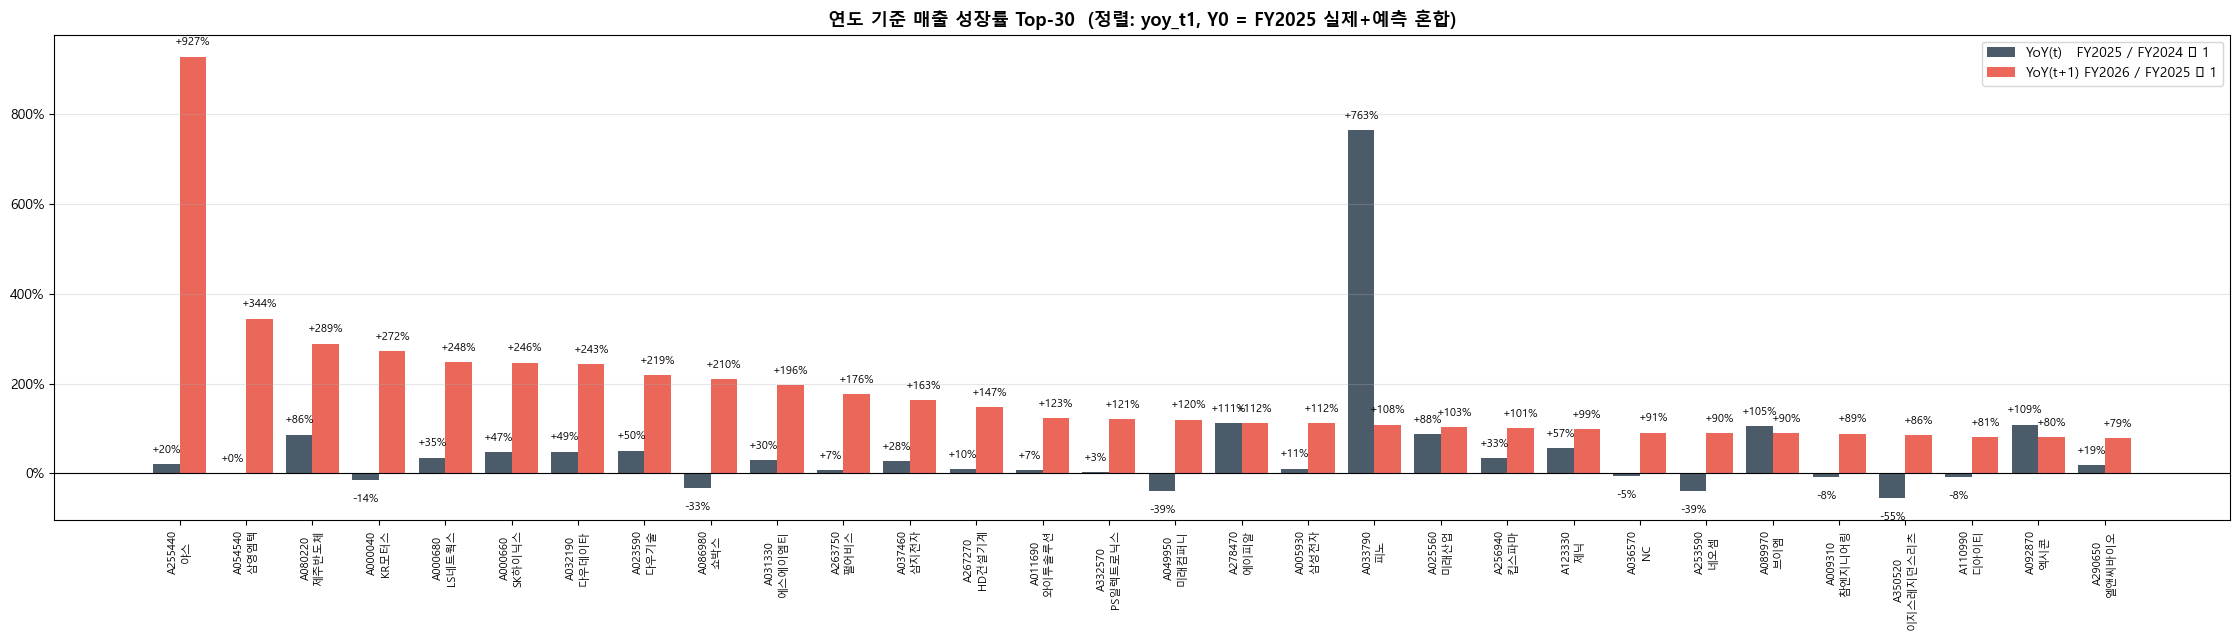

In [19]:
# ── 실행 (정확히 1회) ──────────────────────────────────────────────
fy_df, fy_excluded_df, fy_meta_df, FY_BASE_YEAR_USED = build_fy_growth_table()

fy_saved_path = export_fy_growth_excel(fy_df, fy_excluded_df, fy_meta_df, FY_BASE_YEAR_USED)

# ── 미리보기 (상위 30개) ───────────────────────────────────────────
FY_PREVIEW_N = 300
_money_cols  = ["Y-1", "Y0", "Y+1"] + [f"Y0_Q{i}" for i in range(1, 5)] + [f"Y1_Q{i}" for i in range(1, 5)]
_show_cols   = [c for c in ["ticker", "company_name", "forecast_date", "last_actual_q",
                            "Y-1", "Y0", "Y+1", "yoy_t", "yoy_t1", "Y0_mix"] if c in fy_df.columns]
by = FY_BASE_YEAR_USED
print(f"\n[연도 기준 매출 성장률]  model={FY_MODEL}  Y-1=FY{by-1}  Y0=FY{by}  Y+1=FY{by+1}  "
      f"단위={EXPORT_UNIT_LABEL}  포함 {len(fy_df)}개 / 제외 {len(fy_excluded_df)}개")
display(
    fy_df[_show_cols].head(FY_PREVIEW_N).style
    .format({**{c: "{:,.1f}" for c in _money_cols if c in _show_cols},
             "yoy_t": "{:+.2f}%", "yoy_t1": "{:+.2f}%"}, na_rep="-")
    .background_gradient(subset=["yoy_t", "yoy_t1"], cmap="YlGn")
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("padding", "6px 10px"),
                                      ("font-weight", "bold"), ("background-color", "#34495E"),
                                      ("color", "white")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "6px 10px"),
                                      ("max-width", "150px"), ("white-space", "nowrap")]},
    ])
    .set_caption(f"연도 기준 YoY Top-{FY_PREVIEW_N} (정렬: {FY_SORT_BY}, 전체는 Excel 참조)  |  {fy_saved_path}")
)

# ── 제외 사유 요약 ─────────────────────────────────────────────────
if len(fy_excluded_df) > 0:
    print("\n── 제외 사유별 종목 수 ──")
    print(fy_excluded_df["reason"].str.split("(").str[0].str.strip().value_counts().to_string())

# ── 차트: 상위 30개 YoY(t) vs YoY(t+1) ────────────────────────────
plot_fy_growth_top(fy_df, top_n=30, sort_by=FY_SORT_BY)


## 분기별 예측 버전 보존 설정 (1회성 테이블 정비)

분기마다 매출 예측이 어떻게 바뀌는지 추적하고, 다음 분기 예측이 기존 예측을 덮어쓰지 않게 하려면 저장 테이블을 다음과 같이 한 번 정비해야 합니다.

- **STEP 1 (복구)**: 기존 행의 `created_at` 이 재실행 시 갱신되지 않아 망가진 상태이므로, 실제 실행 시각이 기록된 `updated_at` 기준으로 `created_at` 을 바로잡습니다. → 이번(5월) 예측 전체가 하나의 버전으로 묶입니다.
- **STEP 2 (규칙 변경)**: `UNIQUE KEY` 에 `created_at` 을 포함시켜, 다음 분기 예측이 별도 버전으로 쌓이고 같은 분기끼리 덮어쓰지 않게 합니다.

정비 후 사용 예시
- 특정 버전 조회: `fetch_forecast('A000660', 'Ensemble', forecast_date='2026-05-29')`
- 버전 비교: `get_best_n('Ensemble', forecast_date=['2026-05-29', '2026-08-15'])`
- 저장 노트북은 수정 불필요 (이미 이 키를 의도한 스키마라, 정비 후 자동으로 버전이 쌓임)

> ⚠️ **운영 테이블을 변경합니다. 반드시 DB 백업 후** `DO_MIGRATE = True` 로 바꿔 실행하세요. 기본값은 안전을 위해 `False` 입니다.

In [ ]:
# ════════════════════════════════════════════════════════════════════
# 분기별 예측 버전 보존 설정 (1회성)  ── 실행 전 반드시 DB 백업!
#   STEP 1) 기존 created_at 을 실제 실행일(updated_at)로 복구
#   STEP 2) UNIQUE KEY 를 (date,ticker,indicator,created_at) 로 교체
# ════════════════════════════════════════════════════════════════════
DO_MIGRATE        = False    # 실행하려면 True 로 변경 (백업 먼저!)
REPAIR_CREATED_AT = True     # STEP 1 (created_at 복구) 수행 여부

if DO_MIGRATE:
    import pymysql
    conn = pymysql.connect(
        host=db_info["host"], port=db_info["port"], user=db_info["user"],
        password=db_info["password"], db=db_info["database"], charset="utf8mb4",
    )
    try:
        cur = conn.cursor()

        # updated_at 컬럼 존재 확인
        cur.execute(
            "SELECT COUNT(*) FROM information_schema.COLUMNS "
            "WHERE TABLE_SCHEMA=%s AND TABLE_NAME=%s AND COLUMN_NAME='updated_at'",
            (db_info["database"], FORECAST_TABLE),
        )
        has_updated = cur.fetchone()[0] > 0
        if not has_updated:
            cur.execute(
                f"ALTER TABLE {FORECAST_TABLE} "
                f"ADD COLUMN updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP "
                f"ON UPDATE CURRENT_TIMESTAMP"
            )
            print("[OK] updated_at 컬럼 추가 (이번엔 복구 불가 — 다음 실행분부터 정상 기록)")
            has_updated = True
            REPAIR_CREATED_AT = False   # 방금 추가했으면 복구 기준 데이터가 없음

        # ── STEP 1: created_at 복구 ──────────────────────────────────────
        if REPAIR_CREATED_AT:
            cur.execute(
                f"UPDATE {FORECAST_TABLE} "
                f"SET created_at = DATE(updated_at) "
                f"WHERE created_at <> DATE(updated_at)"
            )
            print(f"[OK] STEP 1 · created_at 복구: {cur.rowcount:,} 행 수정")
        else:
            print("[SKIP] STEP 1 · created_at 복구 건너뜀")

        # ── STEP 2: UNIQUE KEY 교체 ──────────────────────────────────────
        cur.execute(f"SHOW INDEX FROM {FORECAST_TABLE}")
        # Non_unique == 0 이면서 PRIMARY 가 아닌 인덱스 = 기존 UNIQUE KEY
        old_uniques = {row[2] for row in cur.fetchall()
                       if row[1] == 0 and row[2] != "PRIMARY"}
        for nm in old_uniques:
            cur.execute(f"ALTER TABLE {FORECAST_TABLE} DROP INDEX `{nm}`")
            print(f"[OK] STEP 2 · 기존 UNIQUE KEY 제거: {nm}")

        cur.execute(
            f"ALTER TABLE {FORECAST_TABLE} "
            f"ADD UNIQUE KEY uq_date_ticker_ind_created "
            f"(date, ticker, indicator, created_at)"
        )
        conn.commit()
        print("[OK] STEP 2 · UNIQUE KEY (date,ticker,indicator,created_at) 재생성 완료")
        print("      → 다음 분기 예측부터 버전이 분리 저장되며, 같은 분기끼리 덮어쓰지 않습니다.")
        print("      → 저장 노트북은 수정 불필요 (실행일마다 새 버전 자동 누적).")
    except Exception as e:
        conn.rollback()
        print(f"[FAIL] 정비 실패 (롤백됨): {e}")
        print("       UNIQUE KEY 추가가 중복 행 때문에 실패하면, 먼저 중복 정리가 필요합니다.")
    finally:
        conn.close()
else:
    print("DO_MIGRATE=False → 정비를 건너뜁니다. (조회는 v3 패치로 이미 정상)")
